<a href="https://colab.research.google.com/github/Samuelameningayeh/thesis/blob/main/synthetic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# import cmdstanpy
# cmdstanpy.install_cmdstan()


In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
from cmdstanpy import CmdStanModel, cmdstan_path
import arviz as az
from pathlib import Path

from scipy.integrate import odeint
from posterior_plot import plot_posterior_kde_grid

import logging
cmdstanpy_logger = logging.getLogger("cmdstanpy")
cmdstanpy_logger.disabled = True

/media/brasammy/5B6DAD9B6A1F7E40/Projects/cleaned-thesis/myenv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Define the SEIR model

$$ 
\begin{aligned}
\frac{dS_p}{dt} &= -\beta_p S_p \frac{I_p}{N_p}\\

\frac{dE_p}{dt} &= \beta_p S_p \frac{I_p}{N_p} - \sigma_p E_p \\

\frac{dI_p}{dt} &= \sigma_p E_p - \gamma_p I_p\\

\frac{dR_p}{dt} &= \gamma_p I_p
\end{aligned}
$$

Where:
- $ S_p, E_p, I_p, R_p $: Susceptible, Exposed, Infectious, and Recovered individuals in patch $ p $.
- $ N_p $: Total population for patch $ p $.
- $ \beta_p $: Transmission rate in patch $ p $.
- $ \sigma_p $: Rate of progression from Exposed to Infectious (inverse of the latent period).
- $ \gamma_p $: Recovery rate (inverse of the infectious period).

In [2]:
# ---- SEIR ODE system --------------------------------------------------------
def seir(state, t, beta, sigma, gamma, N):
    n=len(N)
    S = state[:n]
    E = state[n:2*n]
    I = state[2*n:3*n]
    R = state[3*n:4*n]
    C = state[4*n:]

    dS = np.zeros(n)
    dE = np.zeros(n)
    dI = np.zeros(n)
    dR = np.zeros(n)
    dC = np.zeros(n)
    
    for i in range(n):
        dS[i] = -beta[i] * S[i] * I[i] / N[i]
        dE[i] =  beta[i] * S[i] * I[i] / N[i] - sigma * E[i]
        dI[i] =  sigma * E[i] - gamma * I[i]
        dR[i] =  gamma * I[i]
        dC[i] = sigma * E[i]
    
    return np.concatenate([dS.flatten(), dE.flatten(), dI.flatten(), dR.flatten(), dC.flatten()])


# Define Parameters

In [3]:
7*53

371

In [15]:
n_regions = 3 
T = 53  #371/7 #96 #679/7
# Time vector
t = np.linspace(0, T, T)

N = [11.5e6, 4.5e6, 6.8e6]  # Guinea, Liberia, Sierra Leone
# N = np.array([1100000, 440000, 680000])
## Get the Parameters
beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = (1/8.5)*7             #incubation rate per week
gamma = (1/10)*7     # 1/infectious period per week (Ebola: ~7 days)

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported

# Initial conditions
E0 = np.array([10, 10, 10])
I0 = np.array([10, 10, 10])
R0 = np.array([0,0,0])
C0 = np.array([0,0,0])
S0 = np.array([N[0]-E0[0]-I0[0], N[1]-E0[1]-I0[1], N[2]-E0[2]-I0[2]])

# initial_state = [guinea, lib, sir]
y0 = np.concatenate([S0.flatten(), E0.flatten(), I0.flatten(), R0.flatten(), C0.flatten()])


# Solve the ODEs

In [16]:
# Simulate SEIR for each region
sol = odeint(seir, y0, t, args=(beta, sigma, gamma, N))

## Get the New Infections and Deaths

In [17]:
n = 3
# Extract and aggregate results
# S = sol[:, :n]
# E = sol[:, n:2*n]
# I = sol[:, 2*n:3*n]
# R = sol[:, 3*n:4*n]
# D = sol[:, 4*n:]

## Total per patch (sum over resident patches i)
S_total = sol[:, :n]
E_total = sol[:, n:2*n]
I_total = sol[:, 2*n:3*n]
R_total = sol[:, 3*n:4*n]
C_total = sol[:, 4*n:]


## get the new infected individuals at each time
Infections = np.zeros([T, n])

for j in range(3):
    ## get new infections
    for i in (range(len(C_total))):

        if (i+1 == len(C_total)):
            new_infections = [0.0,0.0,0.0]
            Infections[i, j] = new_infections[j]
        else:
            new_infections = C_total[i+1] - C_total[i]
            Infections[i+1, j] = new_infections[j]

## Show New infections

In [18]:
Infections[:100]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [1.34226674e+01, 1.64306261e+01, 1.48982812e+01],
       [2.51934417e+01, 3.82768262e+01, 3.13105511e+01],
       [4.45334868e+01, 8.31439619e+01, 6.15819692e+01],
       [7.84093129e+01, 1.80049300e+02, 1.20693286e+02],
       [1.38015383e+02, 3.89814641e+02, 2.36491552e+02],
       [2.42924896e+02, 8.43815062e+02, 4.63359400e+02],
       [4.27565942e+02, 1.82588799e+03, 9.07757841e+02],
       [7.52508534e+02, 3.94775553e+03, 1.77796811e+03],
       [1.32427987e+03, 8.52056846e+03, 3.48085471e+03],
       [2.33011725e+03, 1.83211941e+04, 6.80882229e+03],
       [4.09875546e+03, 3.90785755e+04, 1.32960746e+04],
       [7.20623752e+03, 8.19423570e+04, 2.58786779e+04],
       [1.26585094e+04, 1.65861721e+05, 5.00470935e+04],
       [2.22016331e+04, 3.13175489e+05, 9.56007155e+04],
       [3.88338514e+04, 5.21797612e+05, 1.78404594e+05],
       [6.76053660e+04, 7.16174841e+05, 3.18961548e+05],
       [1.16730781e+05, 7.70291

## Add Noise

In [19]:
from add_noise import Add_noise

observed_cases = Add_noise(Infections, reporting_rate= reporting_rate, phi=phi, seed=0)
c = pd.DataFrame(observed_cases, columns = ['Guinea', 'Liberia', 'Sierra Leone'])


## Create a dataframe

In [20]:
# Create dataset
data = {
    'time': pd.date_range(start='2013-12-28', periods=T, freq='D'),
    'Day': t.astype(int),
    'S_Guinea': S_total[:, 0],
    'E_Guinea': E_total[:, 0],
    'I_Guinea': I_total[:, 0],
    'R_Guinea': R_total[:, 0],
    'C_Guinea': C_total[:, 0],
    'Guinea_New_case': Infections[:, 0],
    'Guinea_Noise' : c['Guinea'],

    'S_Liberia': S_total[:, 1],
    'E_Liberia': E_total[:, 1],
    'I_Liberia': I_total[:, 1],
    'R_Liberia': R_total[:, 1],
    'C_Liberia': C_total[:, 1],
    'Liberia_New_case': Infections[:, 1],
    'Liberia_Noise' : c['Liberia'],

    'S_SierraLeone': S_total[:, 2],
    'E_SierraLeone': E_total[:, 2],
    'I_SierraLeone': I_total[:, 2],
    'R_SierraLeone': R_total[:, 2],
    'C_SierraLeone': C_total[:, 2],
    'SierraLeone_New_case': Infections[:, 2],
    'SierraLeone_Noise' : c['Sierra Leone'],
}

raw = pd.DataFrame(data)
raw.to_csv('Data/synthetic_dataset_no_coupling.csv', index=False)
raw.head()

,time,Day,S_Guinea,E_Guinea,I_Guinea,R_Guinea,C_Guinea,Guinea_New_case,Guinea_Noise,S_Liberia,...,C_Liberia,Liberia_New_case,Liberia_Noise,S_SierraLeone,E_SierraLeone,I_SierraLeone,R_SierraLeone,C_SierraLeone,SierraLeone_New_case,SierraLeone_Noise
0,2013-12-28,0,1.149998e+07,10.000000,10.000000,0.000000,0.000000,0.000000,0,4.499980e+06,...,0.000000,0.000000,0,6.799980e+06,10.000000,10.000000,0.000000,0.000000,0.000000,0
1,2013-12-29,1,1.149995e+07,22.096981,14.916094,8.506574,13.422667,13.422667,8,4.499944e+06,...,16.430626,16.430626,18,6.799949e+06,25.888120,16.102121,8.796160,14.898281,14.898281,19
2,2013-12-30,2,1.149991e+07,39.435300,25.932199,22.683910,38.616109,25.193442,21,4.499870e+06,...,54.707452,38.276826,47,6.799892e+06,51.407954,31.175230,25.033603,46.208832,31.310551,61
3,2013-12-31,3,1.149984e+07,69.478196,45.606621,47.542975,83.149596,44.533487,66,4.499710e+06,...,137.851414,83.143962,76,6.799781e+06,100.807252,61.047505,56.743296,107.790801,61.581969,48
4,2014-01-01,4,1.149971e+07,122.301058,80.271008,91.287901,161.558909,78.409313,74,4.499364e+06,...,317.900715,180.049300,162,6.799564e+06,197.535641,119.617323,118.866765,228.484088,120.693286,99


# Plot the results

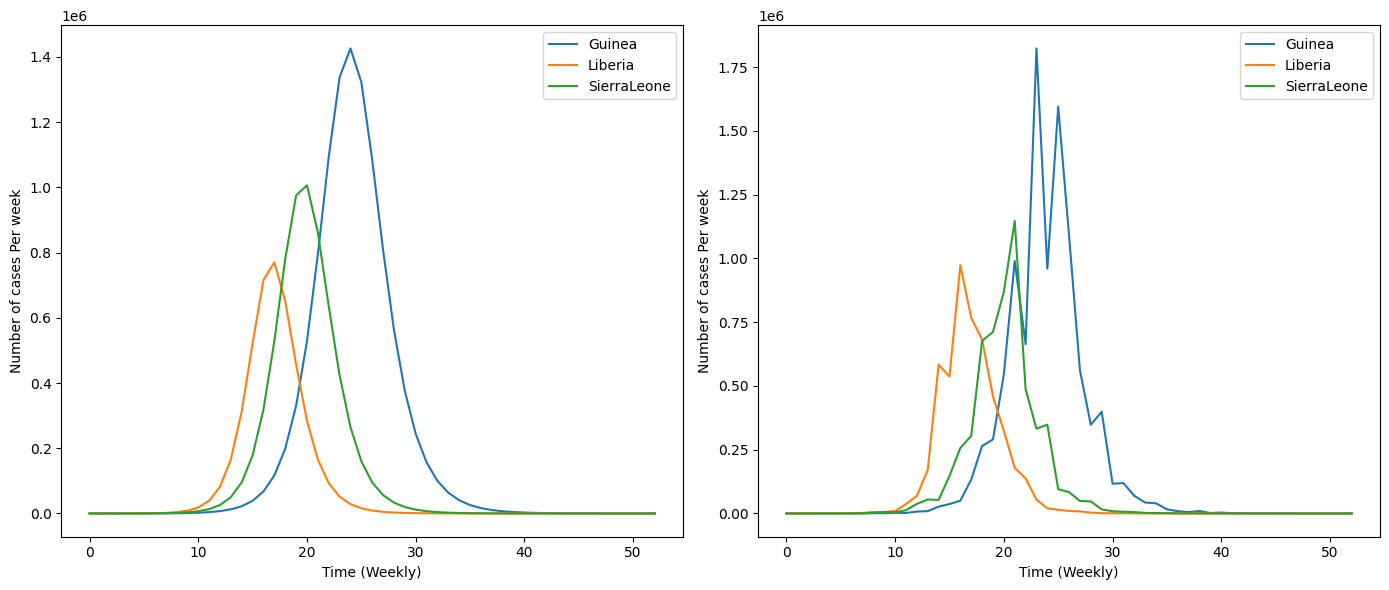

In [21]:
fig, ax = plt.subplots(1,2, figsize = (14, 6))
countries = ['Guinea', 'Liberia', 'SierraLeone']
for i in range(3):
    ax[0].plot(raw[f'{countries[i]}_New_case'])
    ax[0].legend(countries)
    # ax[0].set_title('Number of new infections NO NOISE at time t $[\int_0^T \sigma*$E]')
    ax[0].set_xlabel('Time (Weekly)')
    ax[0].set_ylabel('Number of cases Per week')

    ax[1].plot(raw[f'{countries[i]}_Noise'])
    ax[1].legend(countries)
    # ax[1].set_title('Number of new infections with NOISE at time t $[\int_0^T \sigma*$E]')
    ax[1].set_xlabel('Time (Weekly)')
    ax[1].set_ylabel('Number of cases Per week')

    # ax[2].plot(raw[f'C_{countries[i]}'])
    # ax[2].legend(countries)
    # ax[2].set_title('Number of Infections at time t [$ \sigma$ * E]')
    # ax[2].set_xlabel('Time (Weekly)')
    # ax[2].set_ylabel('Number of cases per week')

plt.tight_layout()
plt.savefig('images/generated_no_coupling.pdf')
plt.show()

In [22]:
# Plot for each country
countries = ['Guinea', 'Liberia', 'SierraLeone']
def plot_SEIR(df, country_name, Death = False, save=False, yscale = False):
    # Extract data for the current country
    S = df[f'S_{country_name}']
    E = df[f'E_{country_name}']
    I = df[f'I_{country_name}']
    R = df[f'R_{country_name}']

    # Create plot
    plt.figure(figsize=(13, 6))
    plt.plot(df['Day'], S, label='Susceptible', color='blue')
    plt.plot(df['Day'], E, label='Exposed', color='orange')
    plt.plot(df['Day'], I, label='Infective', color='red')
    plt.plot(df['Day'], R, label='Removed', color='green')
    if Death:
        D = df[f'D_{country_name}']
        plt.plot(df['Day'], D, label='Death', color='black')

    # Customize the plot
    plt.xlabel('Day')
    plt.ylabel('Number of Individuals')
    plt.title(f'SEIRD Dynamics for {country_name}')
    plt.legend()
    plt.grid(True)
    if yscale:
        plt.yscale('symlog')  # Use symlog scale to handle large ranges
    if save:
        plt.savefig(f'seird_{country_name.lower()}.png')
    plt.show()

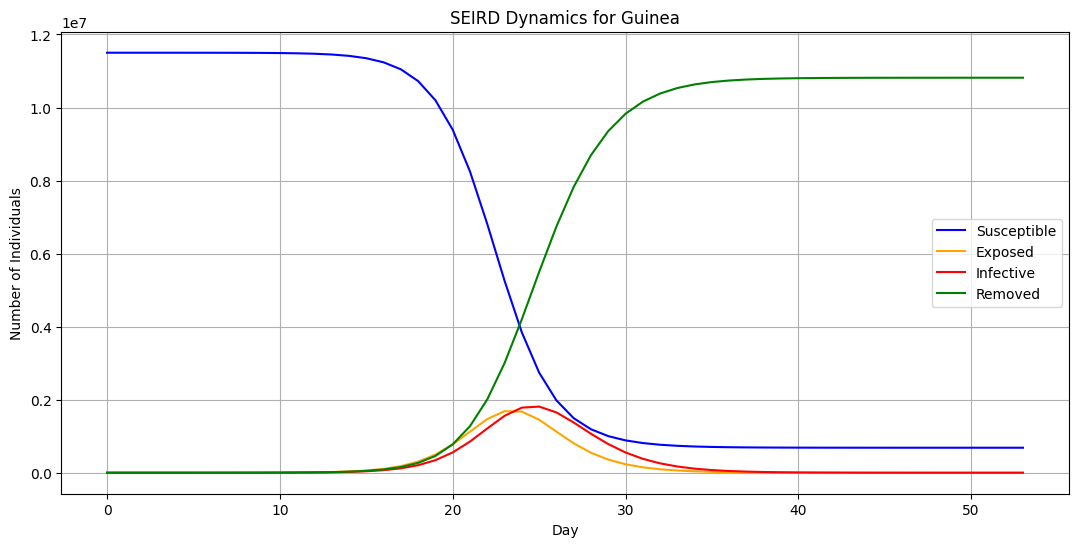

In [24]:
plot_SEIR(raw, 'Guinea')

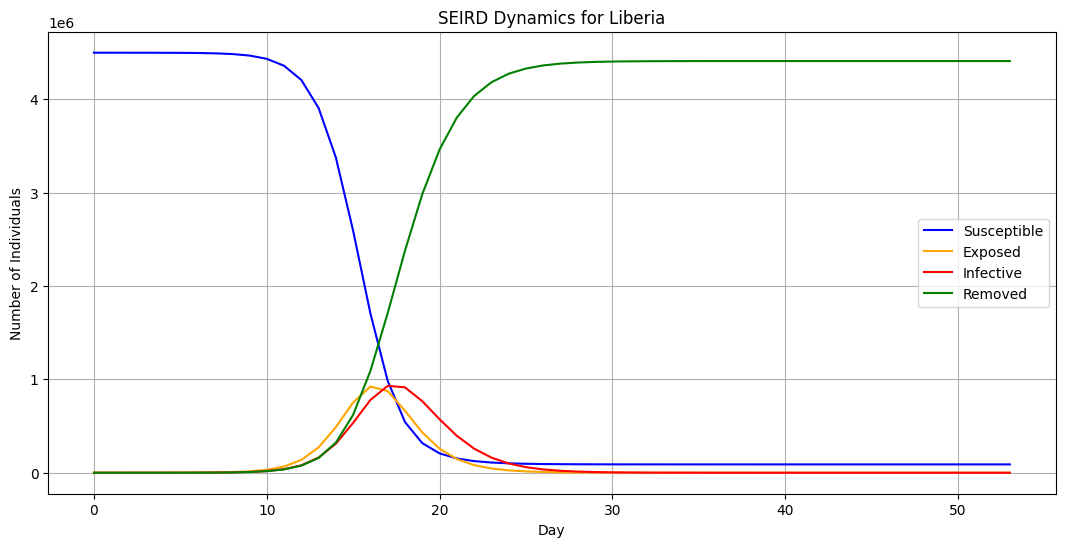

In [25]:
plot_SEIR(raw, 'Liberia')

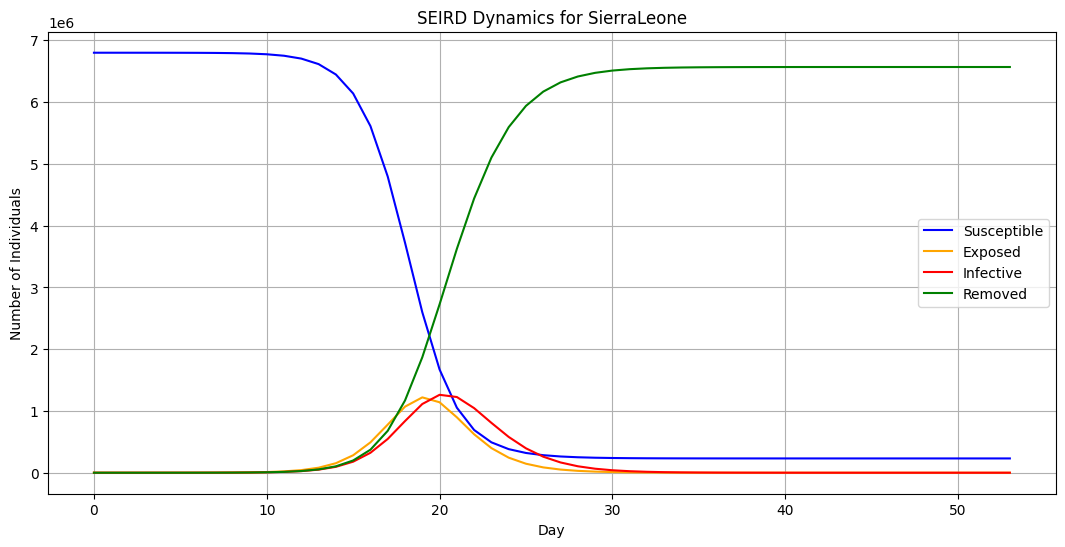

In [26]:
plot_SEIR(raw, 'SierraLeone')

# Create a function to plot Posterior for Parameters

# Fit the Model to daily cases


In [168]:
# # Aggregate cases by country and week
# countries = ['Guinea', 'Liberia', 'Sierra Leone']
# # weekly_cases = df.groupby(['country', pd.Grouper(key='time', freq='W')]).sum().unstack(fill_value=0).T
# weekly_cases1 = raw['Guinea_Noise']
# weekly_cases2 = raw['Liberia_Noise']
# weekly_cases3 = raw['SierraLeone_Noise']

# cases1 = weekly_cases1.values  # Shape: (T, 3)
# cases2 = weekly_cases2.values  # Shape: (T, 3)
# cases3 = weekly_cases3.values  # Shape: (T, 3)

# N = np.array([11.5e6, 4.5e6, 6.8e6])

# beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
# sigma = (1/5)*7 #incubation rate per week
# gamma = (1/6.6)*7 

# phi = 10           # Negative binomial dispersion parameter
# reporting_rate = 1 

# # Define initial conditions
# i0 = [10, 10, 10]
# e0 = [10, 1, 1]
# s0 = N - i0 - e0
# r0 = [0, 0, 0]
# c0 = [0, 0, 0]
# y1 = [s0[0], e0[0], i0[0], r0[0], c0[0]]
# y2 = [s0[1], e0[1], i0[1], r0[1], c0[1]]
# y3 = [s0[2], e0[2], i0[2], r0[2], c0[2]]


In [169]:

# # Make the data struture
# seir_data1 = {
#     "n_days": len(cases1),
#     "y0": y1,
#     "t0": 0,
#     "t": np.arange(1, len(cases1)+1),
#     "N": int(N[0]),
#     "cases": cases1,
#     'beta_value': beta[0],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }

# seir_data2 = {
#     "n_days": len(cases2),
#     "y0": y2,
#     "t0": 0,
#     "t": np.arange(1, len(cases2)+1),
#     "N": int(N[1]),
#     "cases": cases2,
#     'beta_value': beta[1],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }
# seir_data3 = {
#     "n_days": len(cases3),
#     "y0": y3,
#     "t0": 0,
#     "t": np.arange(1, len(cases3)+1),
#     "N": int(N[2]),
#     "cases": cases3,
#     'beta_value': beta[2],
#     'sigma_value': sigma,
#     'gamma_value': gamma,
#     "reporting_rate": reporting_rate
# }

# seir_incidence_model1 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# seir_incidence_model2 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')
# seir_incidence_model3 = CmdStanModel(stan_file = 'stan files/simple_seir.stan')

In [12]:
%run fit_single.py

Compiling stan file for Guinea

Done compiling

Running model fit for Guinea at time 20250607_223731...


chain 1 |          | 00:00 Status






chain 1 |▍         | 00:08 Status






























































chain 1 |██████████| 09:35 Sampling completed                       
chain 2 |██████████| 09:35 Sampling completed                       
chain 3 |██████████| 09:35 Sampling completed                       
chain 4 |██████████| 09:35 Sampling completed                       


Fit for Guinea saved to: outputs/guinea_20250607_223731

Compiling stan file for Liberia

Done compiling

Running model fit for Liberia at time 20250607_224706...


chain 1 |          | 00:00 Status



chain 1 |▍         | 00:31 Status
chain 1 |▉         | 01:05 Iteration:    1 / 2000 [  0%]  (Warmup)
chain 1 |█▎        | 01:09 Iteration:  100 / 2000 [  5%]  (Warmup)
chain 1 |█▊        | 01:34 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 01:37 Iteration:  300 / 2000 [ 15%]  (Warmup)
chain 1 |██▋       | 01:40 Iteration:  400 / 2000 [ 20%]  (Warmup)
chain 1 |███▏      | 01:51 Iteration:  500 / 2000 [ 25%]  (Warmup)
chain 1 |███▋      | 02:06 Iteration:  600 / 2000 [ 30%]  (Warmup)
chain 1 |████      | 02:08 Iteration:  700 / 2000 [ 35%]  (Warmup)
chain 1 |████▌     | 02:11 Iteration:  800 / 2000 [ 40%]  (Warmup)
chain 1 |█████▍    | 02:14 Iteration: 1000 / 2000 [ 50%]  (Warmup)
chain 1 |█████▉    | 02:35 Iteration: 1001 / 2000 [ 50%]  (Sampling)
chain 1 |██████▎   | 02:42 Iteration: 1100 / 2000 [ 55%]  (Sampling)
chain 1 |██████▊   | 02:45 Iteration: 1200 / 2000 [ 60%]  (Sampling)
chain 1 |███████▎  | 02:50 Iteration: 1300 / 2000 [ 


Fit for Liberia saved to: outputs/liberia_20250607_224706

Compiling stan file for SierraLeone

Done compiling

Running model fit for SierraLeone at time 20250607_231525...


chain 1 |          | 00:00 Status


chain 1 |▉         | 01:04 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▊        | 01:30 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 01:35 Iteration:  300 / 2000 [ 15%]  (Warmup)

chain 1 |██▋       | 01:50 Iteration:  400 / 2000 [ 20%]  (Warmup)


chain 1 |███▏      | 01:55 Iteration:  500 / 2000 [ 25%]  (Warmup)


chain 1 |███▋      | 02:07 Iteration:  600 / 2000 [ 30%]  (Warmup)


chain 1 |████      | 02:13 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 02:17 Iteration:  800 / 2000 [ 40%]  (Warmup)


chain 1 |█████▍    | 02:31 Iteration: 1000 / 2000 [ 50%]  (Warmup)


chain 1 |█████▉    | 02:36 Iteration: 1001 / 2000 [ 50%]  (Sampling)




chain 1 |██████▎   | 02:52 Iteration: 1100 / 2000 [ 55%]  (Sampling)


chain 1 |██████▊   | 03:03 Iteration: 1200 / 2000 [ 60%]  (Sampling)


chain 1 |███████▎  | 03:14 Iteration: 1300 / 2000 [ 65%]  (Sampling)

chain 1 |███████▋  | 03:38 Iteration: 1400 / 2000 [ 70%]  (S


Fit for SierraLeone saved to: outputs/sierraleone_20250607_231525

Fits for all countries completed. Check 'output/' directory.


In [14]:
from cmdstanpy import from_csv

# Load Guinea fit
fit1 = from_csv('outputs/guinea_20250607_223731/simple_seir-*_*.csv')
print("Guinea fit loaded")

# Load Liberia fit
fit2 = from_csv('outputs/liberia_20250607_224706/simple_seir-*_*.csv')
print("Liberia fit loaded")

# Load Sierra Leone fit
fit3 = from_csv('outputs/sierraleone_20250607_231525/simple_seir-*_*.csv')
print("Sierra Leone fit loaded")

Guinea fit loaded
Liberia fit loaded
Sierra Leone fit loaded


In [ ]:
print(fit2.diagnose())

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
The E-BFMI, 0.01, is below the nominal threshold of 0.30 which suggests that HMC may have trouble exploring the target distribution.
If possible, try to reparameterize the model.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  sigma, beta, gamma, phi_inv, y[4,1], y[5,1], y[6,1], y[7,1], y[8,1], y[9,1], y[10,1], y[11,1], y[12,1], y[13,1], y[14,1], y[15,1], y[16,1], y[17,1], y[18,1], y[19,1], y[20,1], y[21,1], y[22,1], y[23,1], y[24,1], y[25,1], y[26,1], y[27,1], y[28,1], y[29,1], y[30,1], y[31,1], y[32,1], y[33,1], y[34,1], y[35,1], y[36,1], y[37,1], y[38,1], y[39,1], y[40,1], y[41,1], y[42,1], y[43,1], y[44,1], y[45,1], y[46,1], y[47,1], y[48,1], y[49,1], y[5

In [15]:
fit1_summary = fit1.summary()
fit1_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.504417,0.000331,0.015551,0.015363,0.480720,0.503367,0.530949,2275.93,2078.43,1.00075
beta,1.765210,0.001481,0.067732,0.068429,1.664050,1.761490,1.880450,2168.33,1997.58,1.00089
gamma,0.136632,0.000420,0.020827,0.019804,0.102880,0.136990,0.170112,2488.43,2052.56,1.00136
recovery_time,7.505140,0.027169,1.271730,1.026060,5.878500,7.299790,9.720060,2488.44,2052.56,1.00157
incubation_period,1.984350,0.001285,0.060635,0.060498,1.883420,1.986630,2.080210,2275.96,2078.43,1.00081
R0,13.200100,0.041996,1.973450,1.625520,10.743800,12.892200,16.688000,2578.68,2051.88,1.00245
phi,8.921800,0.042806,2.135970,2.130840,5.752810,8.749580,12.663900,2468.01,2075.06,1.00191
phi_inv,0.118832,0.000627,0.029965,0.027545,0.078964,0.114292,0.173828,2467.94,2075.06,1.00095


In [16]:
fit2_summary = fit2.summary()
fit2_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.669045,0.011647,0.092497,0.029788,0.606584,0.648243,0.855983,150.879,2000.000,1.03546
beta,2.182570,0.024080,0.218104,0.121810,1.963160,2.139910,2.698940,172.641,2000.000,1.03877
gamma,0.202228,0.021724,0.163137,0.038279,0.101725,0.163873,0.656702,128.230,1849.660,1.04003
recovery_time,6.245080,0.186127,2.195500,1.395740,1.522760,6.102290,9.830370,128.232,1849.660,1.03752
incubation_period,1.514150,0.017803,0.144156,0.071350,1.168250,1.542640,1.648570,150.872,2000.000,1.03512
R0,13.286400,0.363343,4.149790,2.660900,4.176170,13.026700,19.863800,122.407,2000.000,1.03783
phi,7.470050,0.103850,2.448260,2.316400,3.993190,7.166530,11.894100,428.895,385.113,1.01432
phi_inv,0.149487,0.003032,0.053127,0.044560,0.084075,0.139537,0.250427,428.897,385.113,1.01432


In [17]:
fit3_summary = fit3.summary()
fit3_summary.filter(items=("sigma", "beta", "gamma", "recovery_time", "incubation_period", "R0", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
sigma,0.623178,0.004577,0.091858,0.041559,0.543536,0.594434,0.834231,534.580,872.727,1.00436
beta,2.233410,0.011237,0.216714,0.176296,1.961720,2.186430,2.646080,428.891,833.369,1.00716
gamma,0.281804,0.009074,0.154199,0.056276,0.152060,0.217794,0.619398,412.361,927.538,1.00746
recovery_time,4.326020,0.085635,1.600190,1.298940,1.614470,4.591500,6.576360,412.361,927.538,1.00746
incubation_period,1.632000,0.009511,0.188808,0.120239,1.198710,1.682270,1.839810,534.578,872.727,1.00436
R0,9.391410,0.160215,3.012900,2.161770,4.041290,9.897870,13.577100,421.628,821.591,1.00729
phi,6.482190,0.063464,1.828280,1.766900,3.861810,6.309400,9.798680,814.446,1653.460,1.00269
phi_inv,0.167253,0.001782,0.049710,0.044247,0.102054,0.158494,0.258947,814.443,1653.460,1.00439


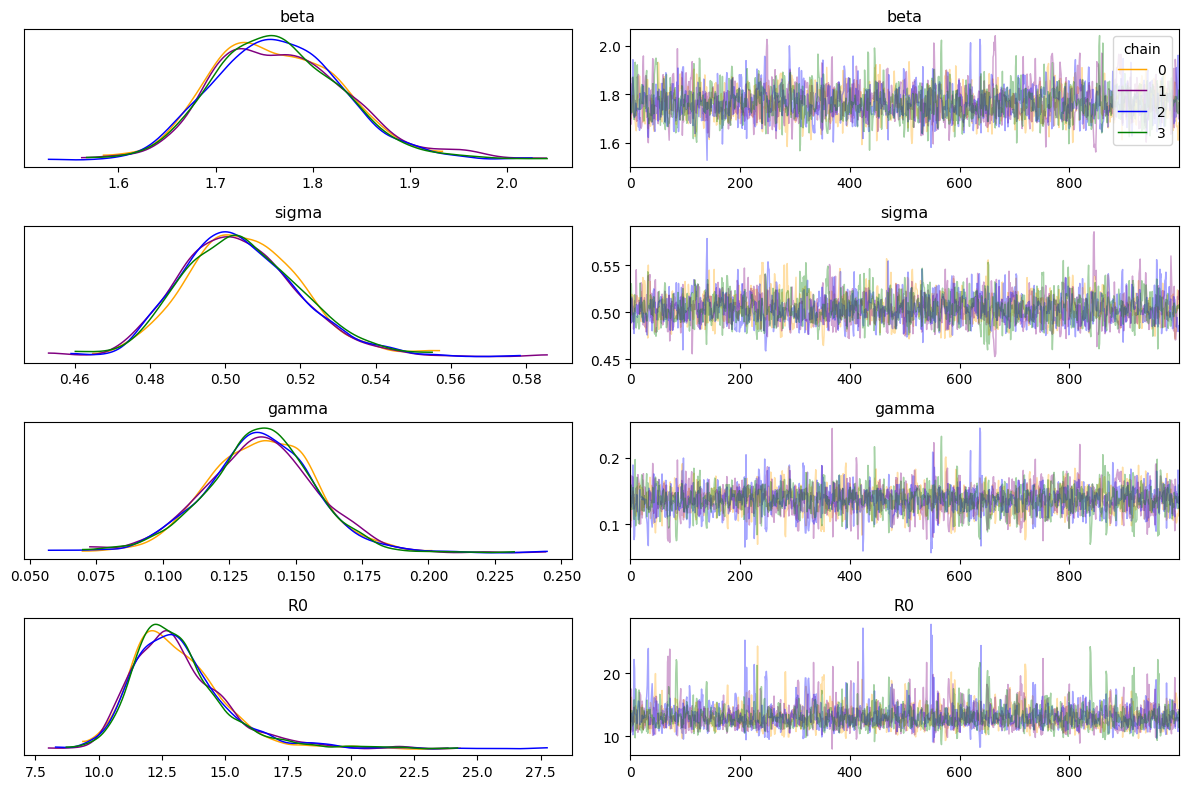

In [18]:
## trace plots
axes = az.plot_trace(fit1, 
              var_names=["beta", "sigma", "gamma", "R0"],
            #   figsize=(12, 8),
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)

plt.tight_layout()
plt.show()

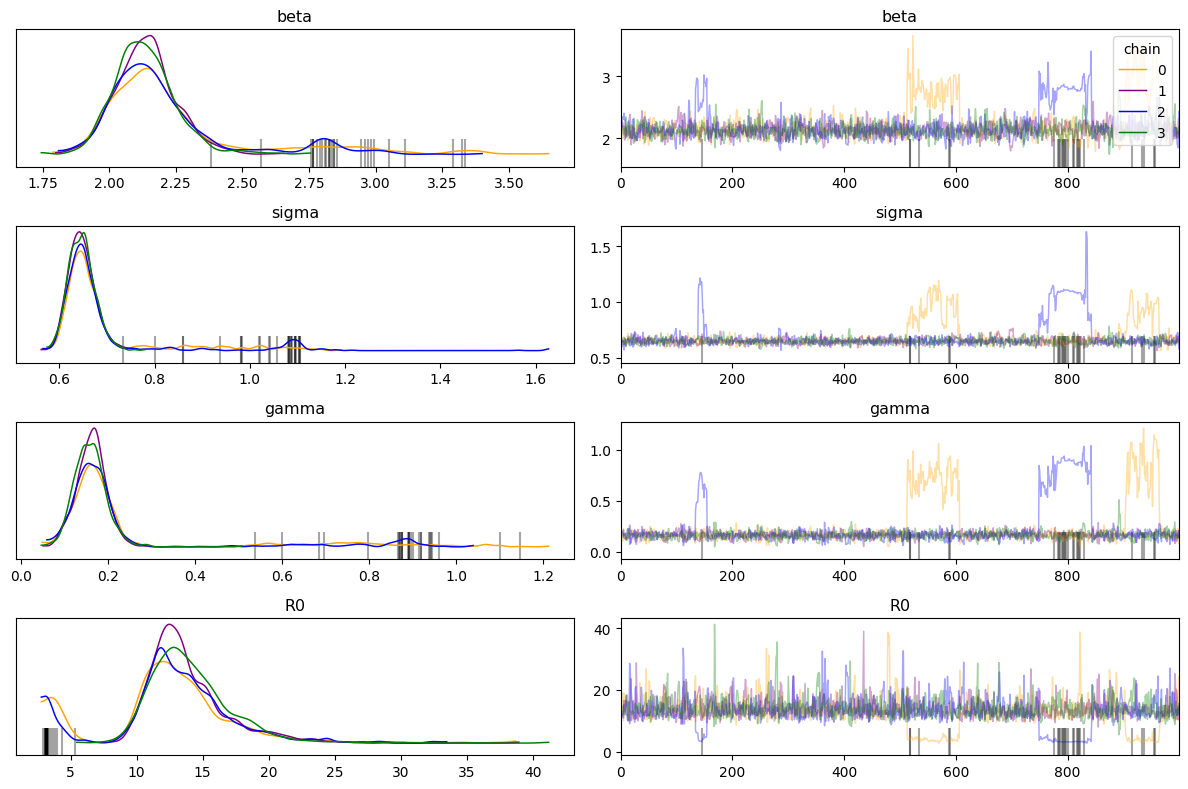

In [21]:
az.plot_trace(fit2, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

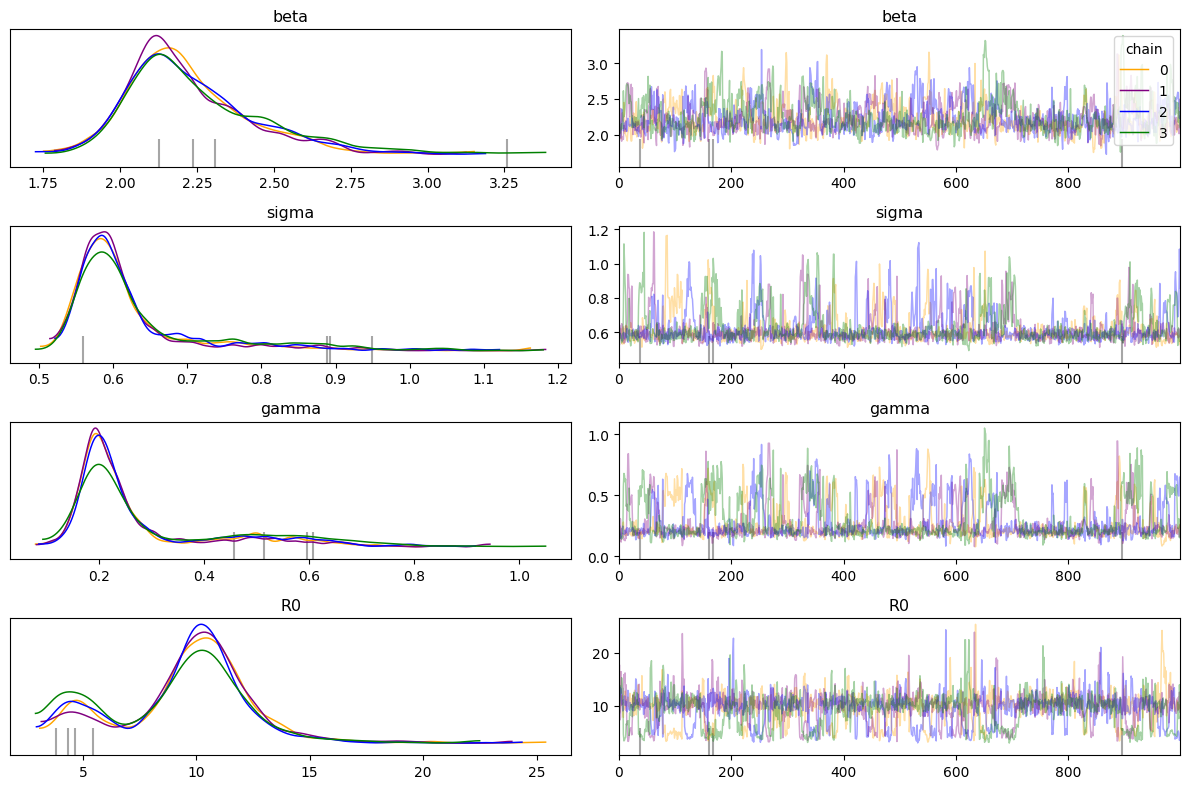

In [22]:
az.plot_trace(fit3, var_names=["beta", "sigma", "gamma", "R0"],
              chain_prop={"color": ["orange", "purple", "blue", "green"]},
              legend=True)
plt.tight_layout()
plt.show()

In [ ]:
# Extract posterior samples
post_guinea = fit1.draws_pd()
post_liberia = fit2.draws_pd()
post_sierra = fit3.draws_pd()

# ## save the posterior samples
# post_guinea.to_csv('./Data/posterior_samples_guinea.csv', index=False)
# post_liberia.to_csv('./Data/posterior_samples_liberia.csv', index=False)
# post_sierra.to_csv('./Data/posterior_samples_sierra.csv', index=False)

# Posterior Predictive Checks

In [ ]:
fit1_summary.filter(like="pred_incidence", axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
pred_incidence[1],16.59500,0.129185,7.957190,7.4130,6.0,15.0,32.00,3862.82,3955.72,1.00016
pred_incidence[2],23.28900,0.172256,10.721500,10.3782,9.0,22.0,43.00,3910.84,3833.26,1.00086
pred_incidence[3],33.51250,0.240548,14.552000,13.3434,13.0,32.0,61.00,3775.80,3830.32,1.00112
pred_incidence[4],47.04950,0.349578,20.677300,19.2738,19.0,44.0,84.05,3615.36,3892.30,1.00043
pred_incidence[5],68.36000,0.482790,29.019400,26.6868,28.0,65.0,122.00,3603.69,3748.39,1.00013
...,...,...,...,...,...,...,...,...,...,...
pred_incidence[92],0.02925,NaN,0.172922,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[93],0.02600,NaN,0.160719,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[94],0.02075,NaN,0.144307,0.0000,0.0,0.0,0.00,NaN,NaN,NaN
pred_incidence[95],0.01500,NaN,0.123608,0.0000,0.0,0.0,0.00,NaN,NaN,NaN


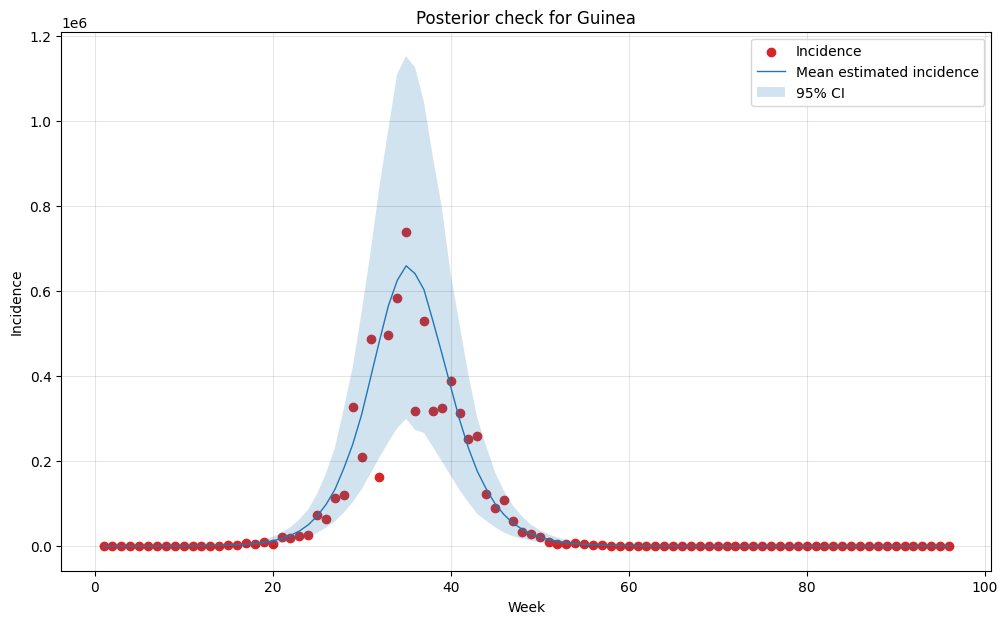

In [ ]:
post_pred1 = pd.DataFrame(fit1_summary.filter(like="pred_incidence", axis=0))
post_pred1["t"] = range(1, T+1)
post_pred1["incidence"] = list(cases1)
post_pred1 = post_pred1.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Guinea')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred1.index, y = post_pred1.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred1.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred1.index, y1 = post_pred1['5%'], y2 = post_pred1['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

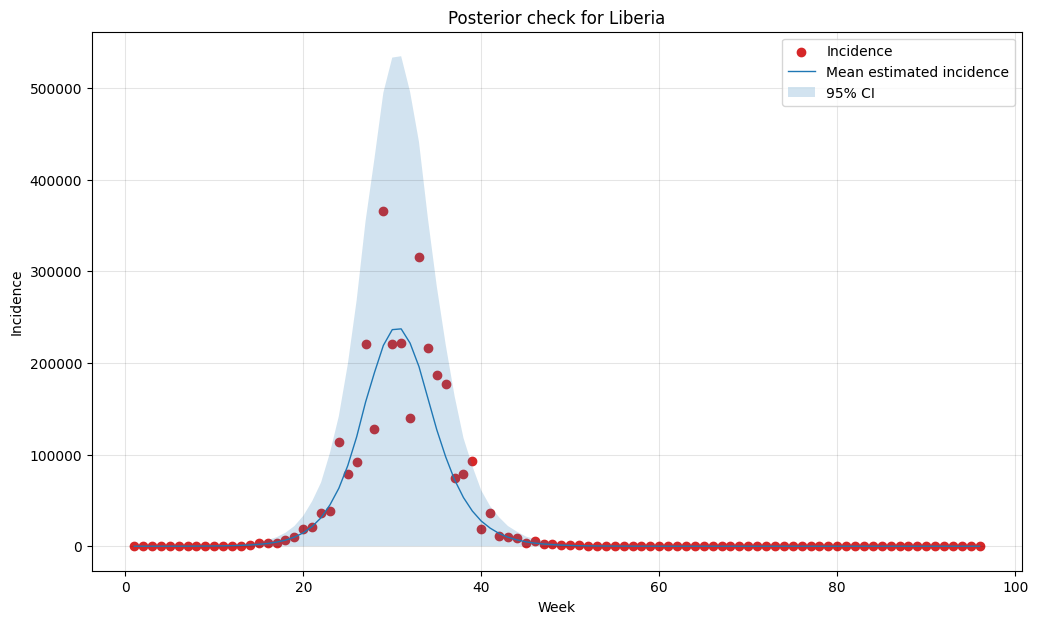

In [ ]:
post_pred2 = pd.DataFrame(fit2_summary.filter(like="pred_incidence", axis=0))
post_pred2["t"] = range(1, T+1)
post_pred2["incidence"] = list(cases2)
post_pred2 = post_pred2.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Liberia')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred2.index, y = post_pred2.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred2.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred2.index, y1 = post_pred2['5%'], y2 = post_pred2['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

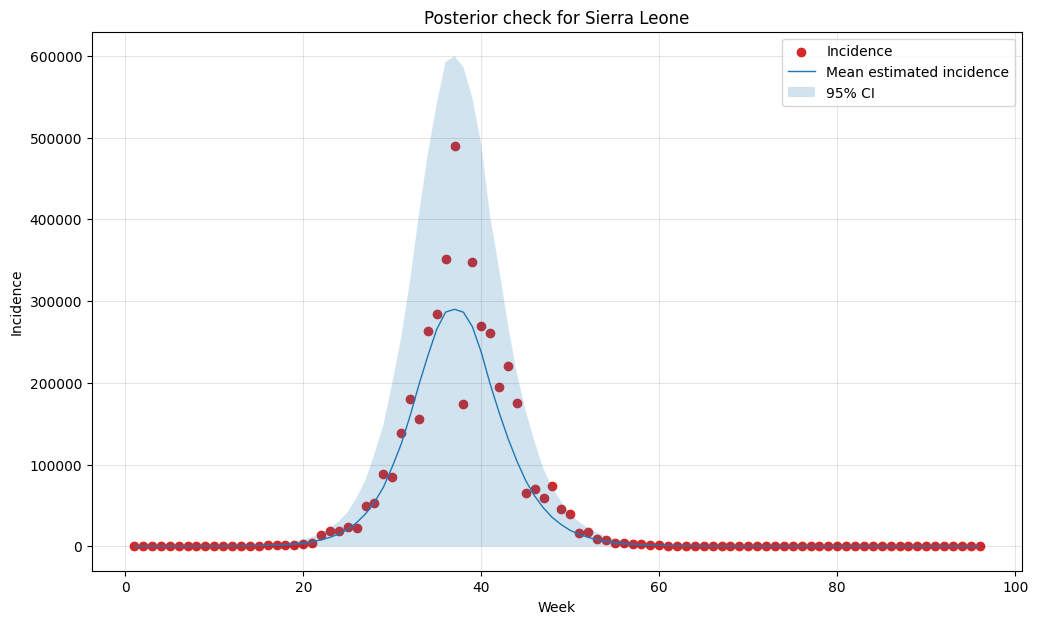

In [ ]:
post_pred3 = pd.DataFrame(fit3_summary.filter(like="pred_incidence", axis=0))
post_pred3["t"] = range(1, T+1)
post_pred3["incidence"] = list(cases3)
post_pred3 = post_pred3.set_index("t")

plt.figure(figsize=(12, 7))
plt.grid(True, which='both', color = 'k', alpha = 0.1)
plt.title(f'Posterior check for Sierra Leone')
plt.ylabel('Incidence')
plt.xlabel('Week')
plt.scatter(x = post_pred3.index, y = post_pred3.incidence, color = 'tab:red', label = "Incidence")
plt.plot(post_pred3.Mean, color = 'tab:blue', linewidth= 1, label = "Mean estimated incidence")
plt.fill_between(x = post_pred3.index, y1 = post_pred3['5%'], y2 = post_pred3['95%'], alpha=0.2, label="95% CI")
# plt.facecolor('white')
plt.legend(loc = "upper right")

In [23]:
# Assuming `fit` is your CmdStanMCMC object from fitting the model
parameters1 = ["beta", "sigma", "recovery_time", "gamma", "incubation_period", "R0","phi"]

beta = np.array([0.3, 0.4, 0.35])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = 1/8.5*7 #incubation rate per week
gamma = 1/13*7  

phi = 10           # Negative binomial dispersion parameter
reporting_rate = 1 #0.8  # Proportion of cases reported
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

t1 = {'beta':beta[0],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[0], 'recovery_time':rec,
    'incubation_period': incu}

t2 = {'beta':beta[1],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[1], 'recovery_time':rec,
    'incubation_period': incu}

t3 = {'beta':beta[2],'sigma': sigma, 'gamma': gamma, 'phi': phi ,
    'reporting_rate':reporting_rate, 'R0': r[2], 'recovery_time':rec,
    'incubation_period': incu}

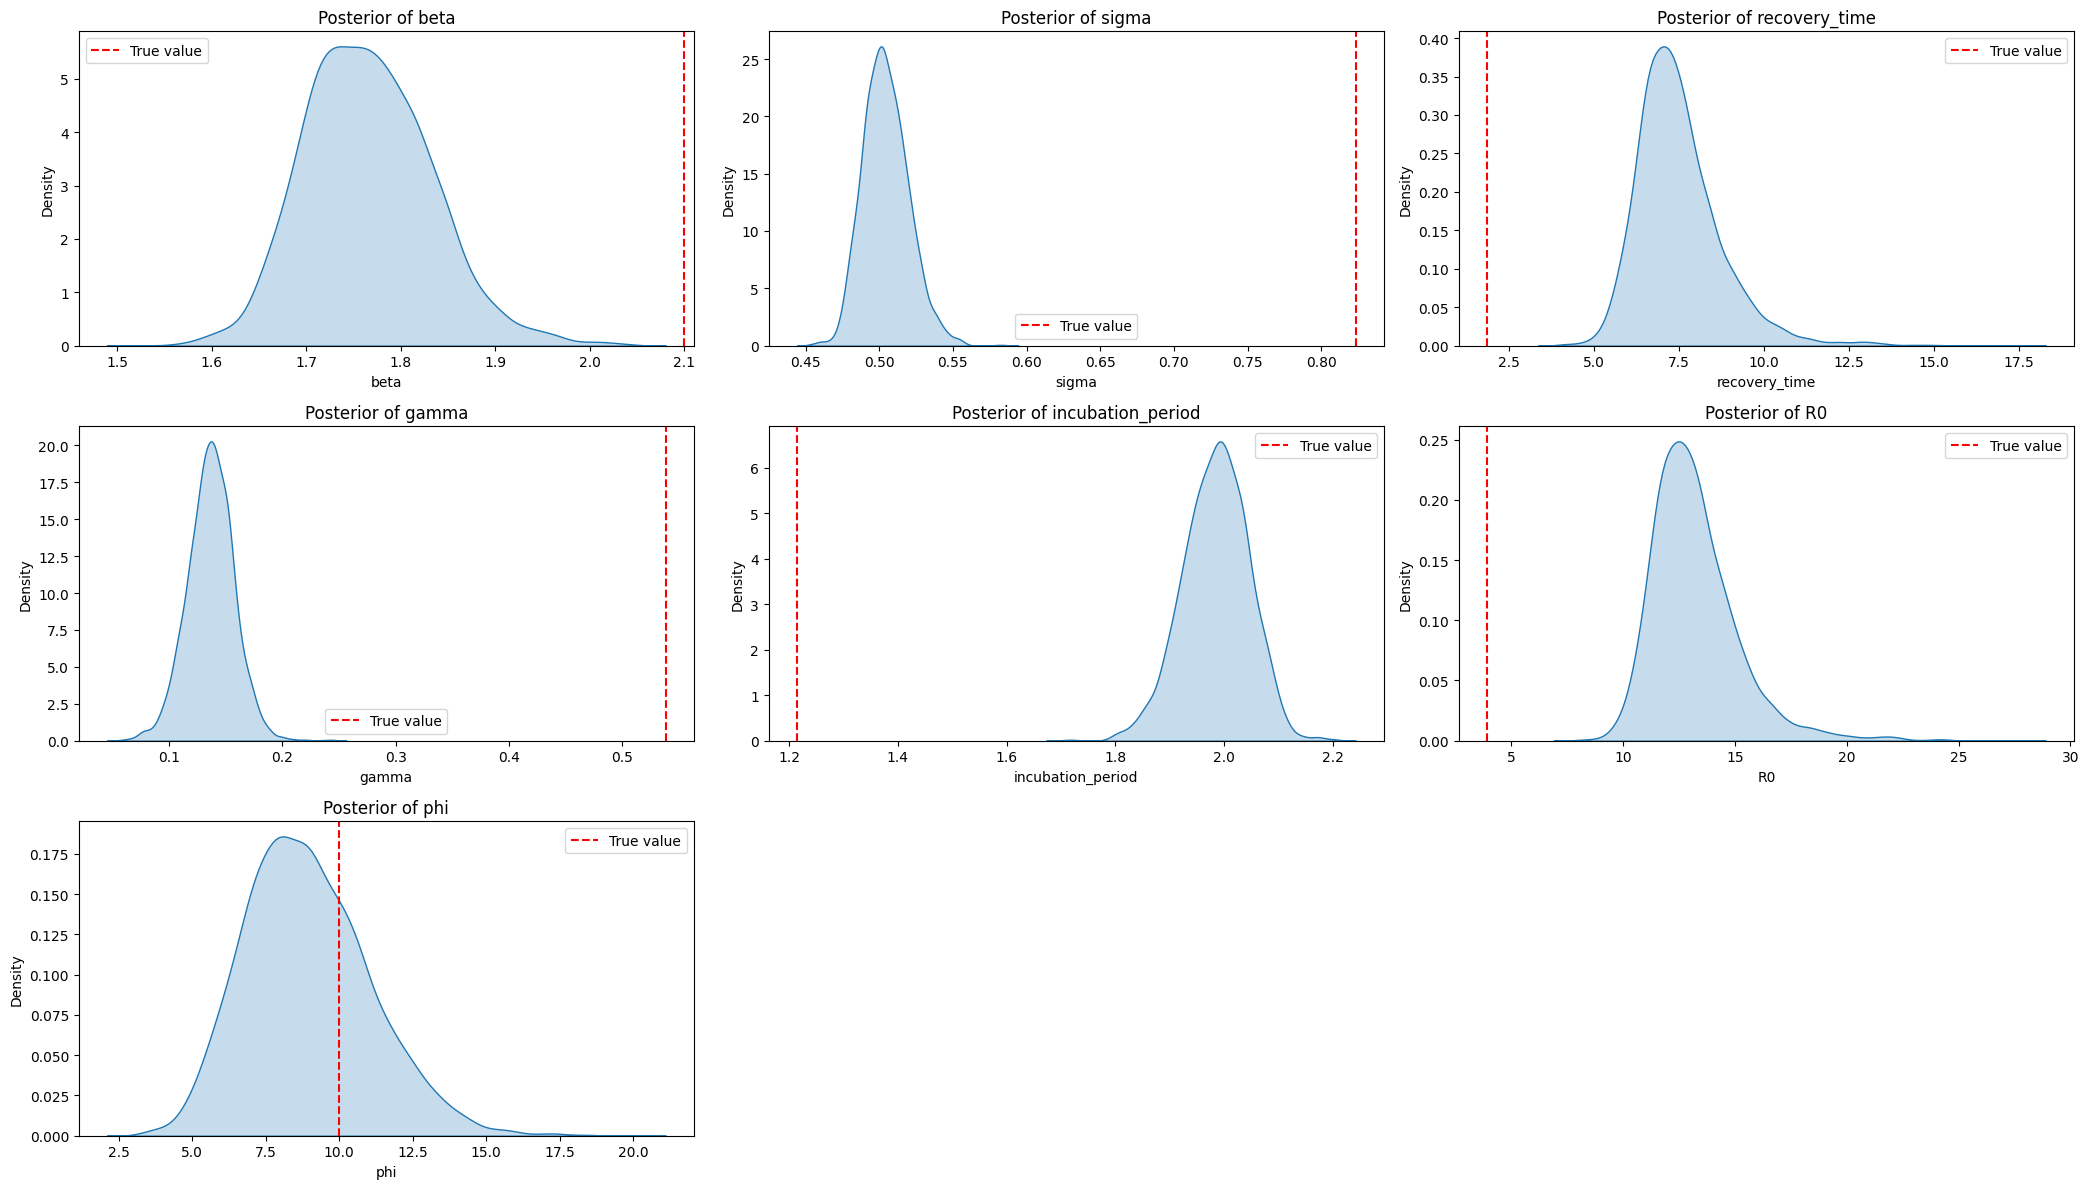

In [25]:
from posterior_plot import plot_posterior_kde_grid

plot_posterior_kde_grid(fit1, parameters1, 3,t1)

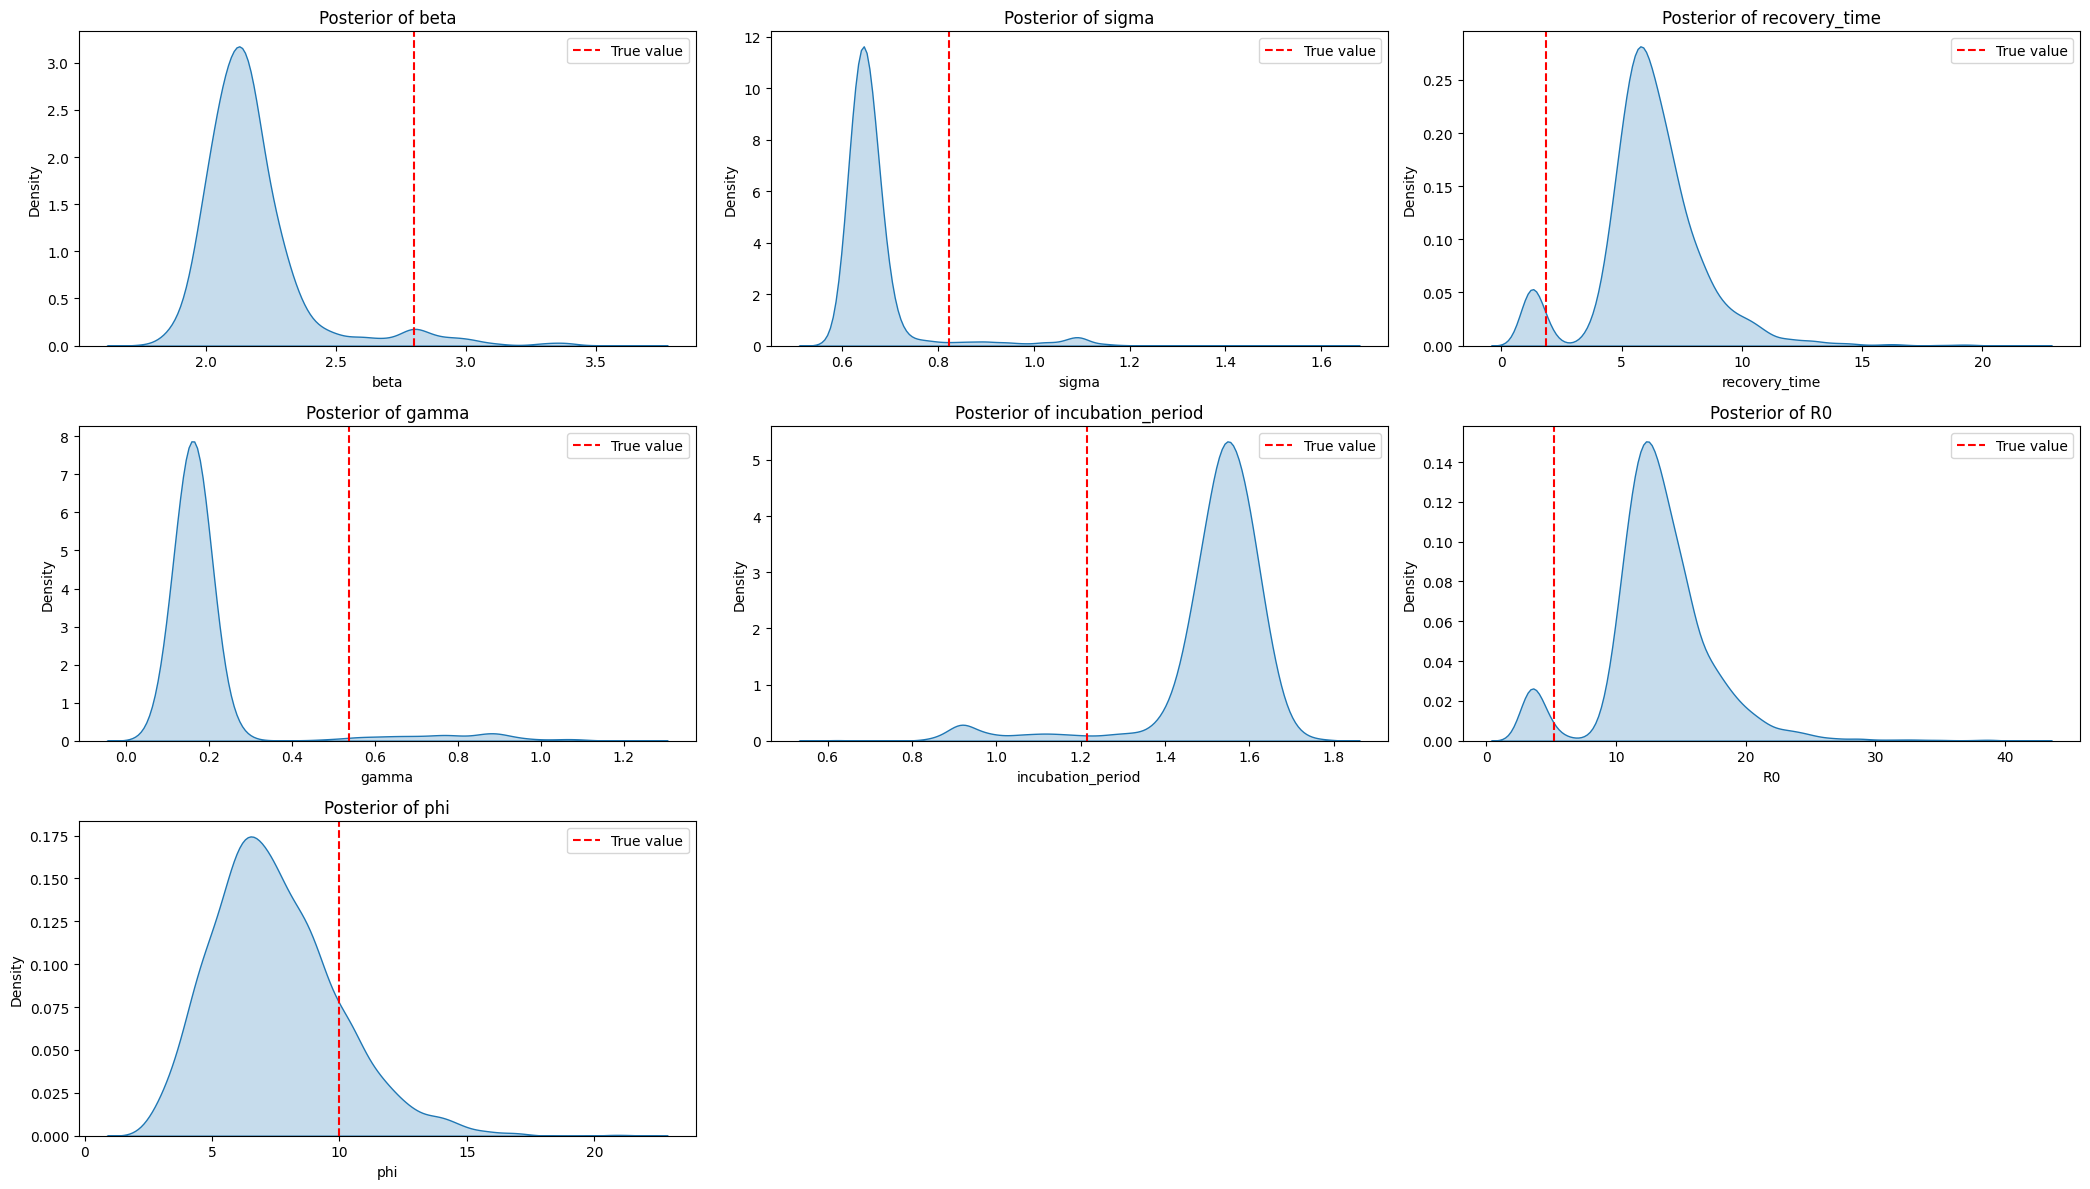

In [26]:
plot_posterior_kde_grid(fit2, parameters1, 3,t2)

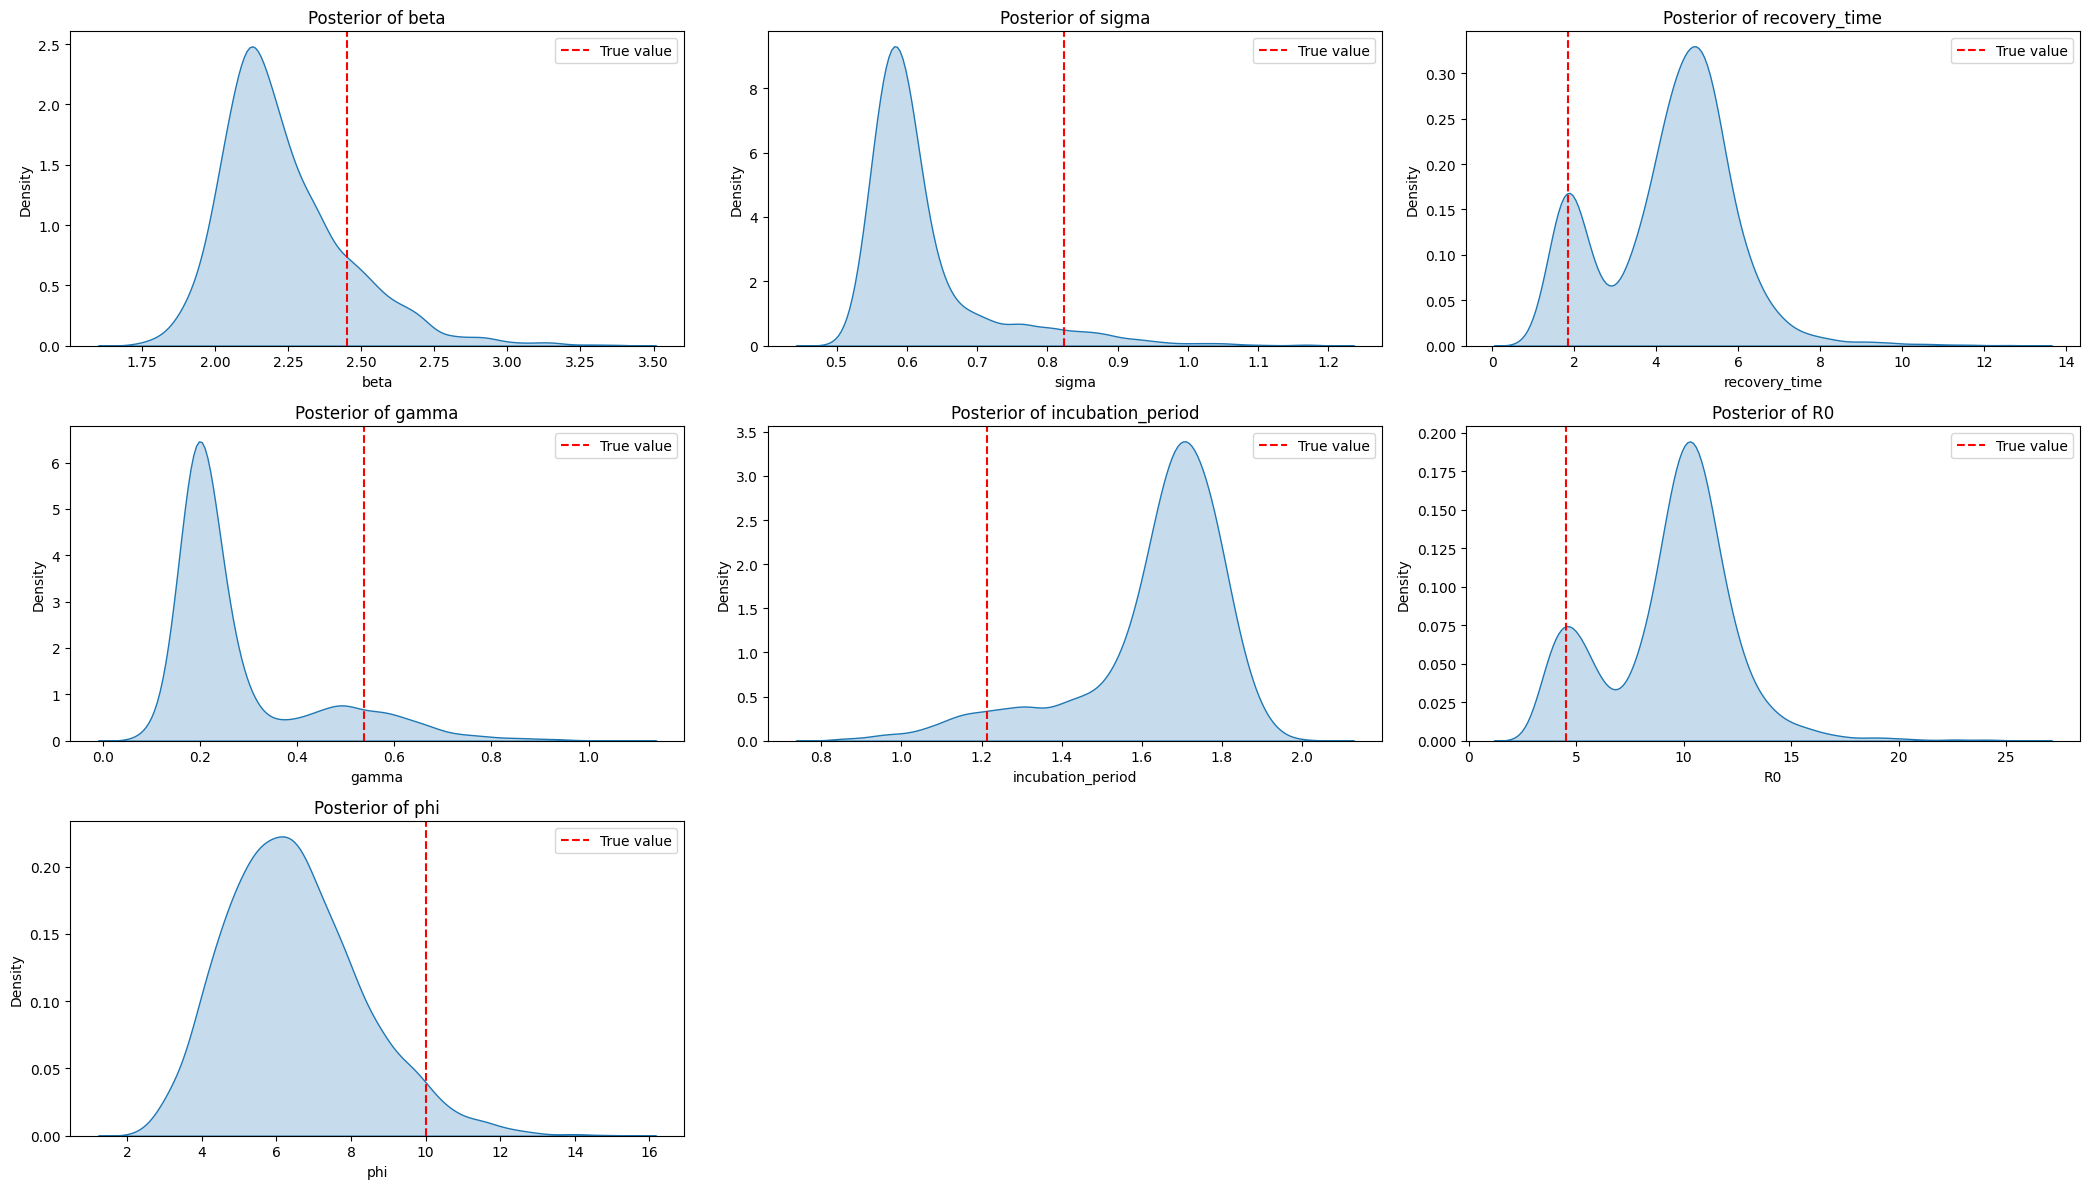

In [27]:
plot_posterior_kde_grid(fit3, parameters1, 3,t3)

## Plot SEIR Compartments

In [ ]:

def plot_compartment(fit, country_idx):
    # Time points and countries
    weeks = np.arange(fit.stan_variable('incidence').shape[1])  # Number of weeks
    countries = ['Guinea', 'Liberia', 'Sierra Leone']

    # Plot incidence (infectious) and reconstructed other compartments
    # for i in range(countries):
    # Create figure
    plt.figure(figsize=(12, 7))
    incidence = np.mean(fit.stan_variable('incidence'), axis=0)

    # Reconstruct approximate compartments (scaled by reporting rate)
    I = incidence
    R = np.cumsum(I) * np.mean(fit.stan_variable('gamma'))
    E = np.roll(I, 1) / np.mean(fit.stan_variable('sigma'))  # Exposed ~ delayed infectious
    # E[0] = 0
    S = N[country_idx] - E - I - R

    # Convert to fractions
    S_frac = S / N[country_idx]
    E_frac = E / N[country_idx]
    I_frac = I / N[country_idx]
    R_frac = R / N[country_idx]

    # Plot
    plt.plot(weeks, S_frac, 'b', label='Susceptible')
    plt.plot(weeks, E_frac, 'y', label='Exposed')
    plt.plot(weeks, I_frac, 'r', label='Infectious')
    plt.plot(weeks, R_frac, 'g', label='Recovered')

    # Formatting
    plt.title(f'{countries[country_idx]} (R0={np.mean(fit.stan_variable("R0")):.2f})')
    plt.ylabel('Fraction of Population')
    plt.grid(True, alpha=0.3)
    # ax.set_ylim(0, 1)

    plt.legend(loc='upper right')
    plt.xlabel('Weeks since outbreak start')
    # plt.tight_layout()
    plt.show()                                                                                      

In [ ]:
# plot_compartment(fit1, country_idx=0)
# plot_compartment(fit2, country_idx=1)
# plot_compartment(fit3, country_idx=2)

# FITTING FOR 3 PATCHES

In [32]:
weekly = raw[['Guinea_Noise', 'Liberia_Noise', 'SierraLeone_Noise']]
weekly.tail()

,Guinea_Noise,Liberia_Noise,SierraLeone_Noise
91,0,0,0
92,0,0,0
93,0,0,0
94,0,0,0
95,0,0,0


In [28]:
%run fit_multi.py

Running model fit for All Patches at time 20250607_233707...

Done compiling...Now Sampling!


chain 1 |          | 00:00 Status



chain 1 |▍         | 00:00 Status

chain 1 |▉         | 03:06 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 06:15 Iteration:  100 / 2000 [  5%]  (Warmup)


chain 1 |█▊        | 09:53 Iteration:  200 / 2000 [ 10%]  (Warmup)


chain 1 |██▎       | 12:11 Iteration:  300 / 2000 [ 15%]  (Warmup)


chain 1 |██▋       | 15:53 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 18:55 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 21:36 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 23:46 Iteration:  700 / 2000 [ 35%]  (Warmup)


chain 1 |████▌     | 26:20 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 28:53 Iteration: 1000 / 2000 [ 50%]  (Warmup)



chain 1 |█████▉    | 31:49 Iteration: 1001 / 2000 [ 50%]  (Sampling)


chain 1 |██████▎   | 34:41 Iteration: 1100 / 2000 [ 55%]  (Sampling)

chain 1 |██████▊   | 37:09 Iteration: 1200 / 2000 [ 60%]  (Sampling)


chain 1 |███████▎  | 40:15 It



Fit for all Patches saved to: outputs/all_Patches_20250607_233707
Fits for all Patches completed. Check 'output/' directory.


In [29]:
# Load Guinea fit
fit_multi_model = from_csv('outputs/all_Patches_20250607_233707/mult-*_*.csv')
print("All fit loaded")
print(fit_multi_model.diagnose())

All fit loaded
Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

The following parameters had rank-normalized split R-hat greater than 1.01:
  beta[1], beta[2], beta[3], sigma, gamma, phi_inv, y[2,1,1], y[3,1,1], y[2,2,1], y[3,2,1], y[1,3,1], y[2,3,1], y[3,3,1], y[1,4,1], y[2,4,1], y[3,4,1], y[1,5,1], y[3,5,1], y[1,6,1], y[3,6,1], y[1,7,1], y[3,7,1], y[1,8,1], y[2,8,1], y[3,8,1], y[1,9,1], y[2,9,1], y[3,9,1], y[1,10,1], y[2,10,1], y[3,10,1], y[1,11,1], y[2,11,1], y[3,11,1], y[1,12,1], y[2,12,1], y[1,13,1], y[2,13,1], y[1,14,1], y[2,14,1], y[3,14,1], y[1,15,1], y[2,15,1], y[3,15,1], y[1,16,1], y[2,16,1], y[3,16,1], y[2,17,1], y[3,17,1], y[1,18,1], y[2,18,1], y[3,18,1], y[1,19,1], y[2,19,1], y[3,19,1], y[1,20,1], y[2,2

In [30]:
multy_fit_summary = fit_multi_model.summary()
multy_fit_summary.filter(items=("beta[1]","beta[2]", "beta[3]", 
                               "sigma", "gamma", "recovery_time", 
                                "R0[1]","R0[2]", "R0[3]", 
                               "incubation_period", "phi", "phi_inv"), axis=0)

,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,R_hat
beta[1],1.766820,0.162753,0.238197,0.086621,1.556600,1.655970,2.241250,7.25534,2000.0000,1.52976
beta[2],2.483960,0.128290,0.200967,0.127274,2.264350,2.413680,2.894220,7.30076,2000.0000,1.51925
beta[3],2.146470,0.151786,0.226803,0.105398,1.922740,2.050150,2.602350,7.23972,2000.0000,1.52823
sigma,0.637885,0.068410,0.103479,0.022768,0.562267,0.588657,0.868964,7.17937,2000.0000,1.52820
gamma,0.271724,0.133877,0.193043,0.025035,0.139721,0.168283,0.657078,7.25070,2000.0000,1.53067
recovery_time,5.079500,1.390100,2.027250,0.912259,1.521890,5.942340,7.157110,7.25070,2000.0000,1.53067
R0[1],8.504290,1.987230,2.878400,1.102570,3.309150,9.783630,11.248000,7.23678,2000.0000,1.53070
R0[2],12.252900,3.090850,4.503320,2.007000,4.223300,14.149200,16.810700,7.21575,2000.0000,1.53017
R0[3],10.468300,2.550930,3.710750,1.557840,3.820660,12.064100,14.147600,7.22157,2000.0000,1.53081
incubation_period,1.601710,0.142676,0.211188,0.066168,1.150800,1.698780,1.778520,7.17937,2000.0000,1.52820


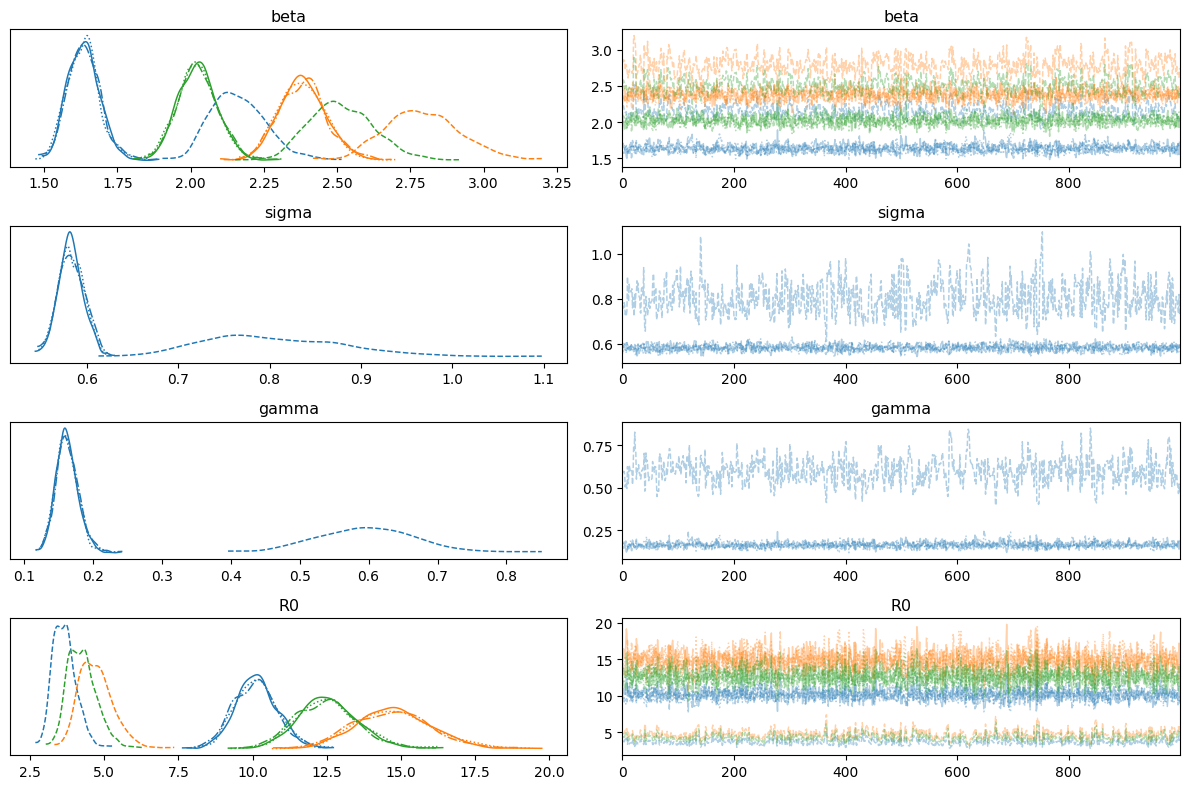

In [31]:
# # Extract posterior samples
# post_no = fit_multi_model.draws_pd()

# ## save the posterior samples
# post_no.to_csv('./Data/posterior_samples_no_coupling.csv', index=False)
az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

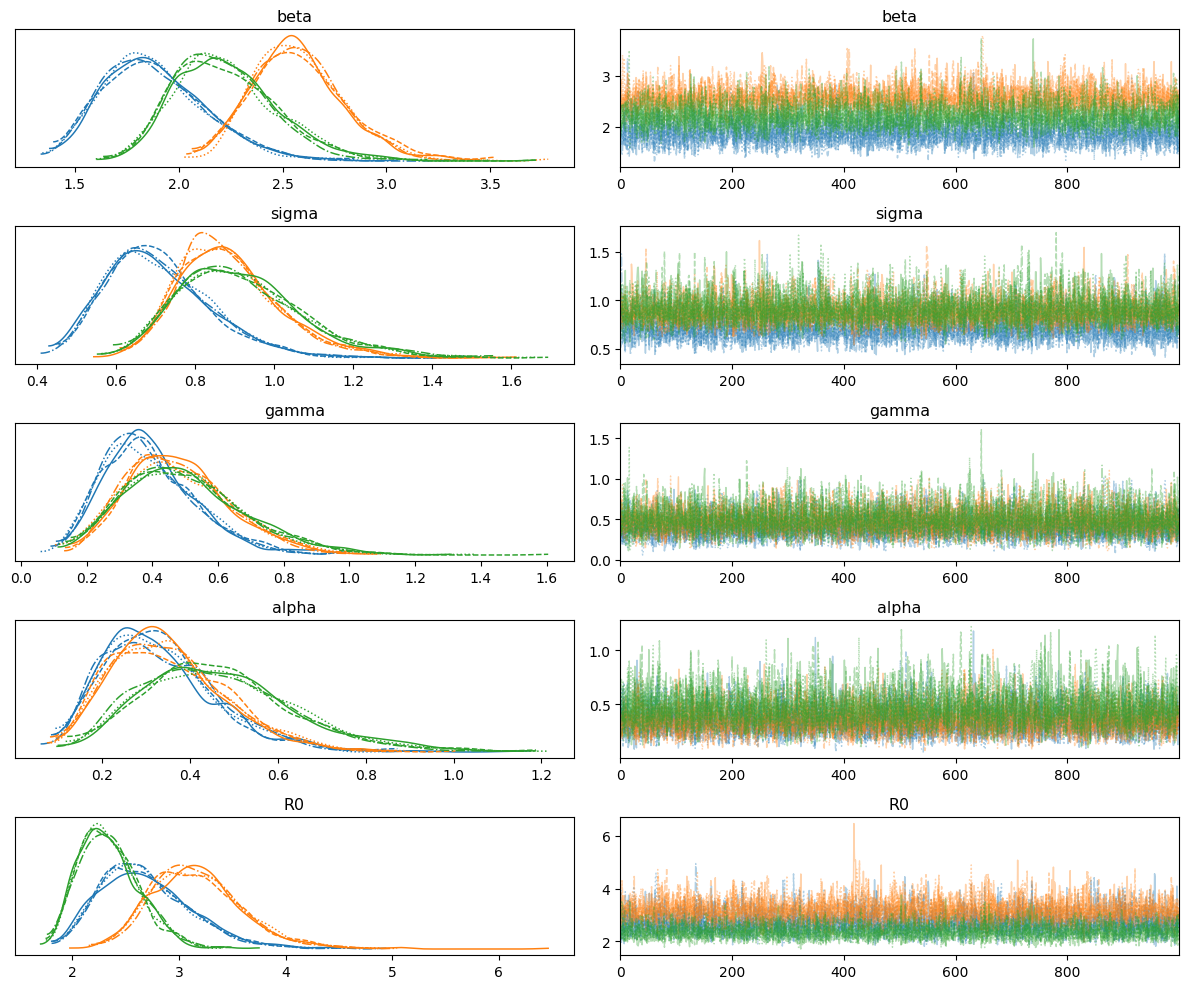

In [ ]:

az.plot_trace(fit_multi_model, var_names=["beta", "sigma", "gamma", "R0"])
plt.tight_layout()
plt.show()

# POSTERIOR PREDICTIVE CHECK

In [ ]:
# Get available variables
# Assuming `fit` is your CmdStanMCMC object from fitting the model
posterior_samples = fit_multi_model.draws_pd()  # returns a pandas DataFrame

beta = np.array([0.25, 0.27, 0.26])*7  # Transmission rate per week (R0 = beta/gamma)
sigma = 1/5*7 #incubation rate per week
gamma = 1/6.6*7    # 1/infectious period (Ebola: ~7 days)

phi = 10            # Negative binomial dispersion parameter
reporting_rate = 1
r = beta/gamma
rec = 1.0/gamma
incu = 1.0 / sigma

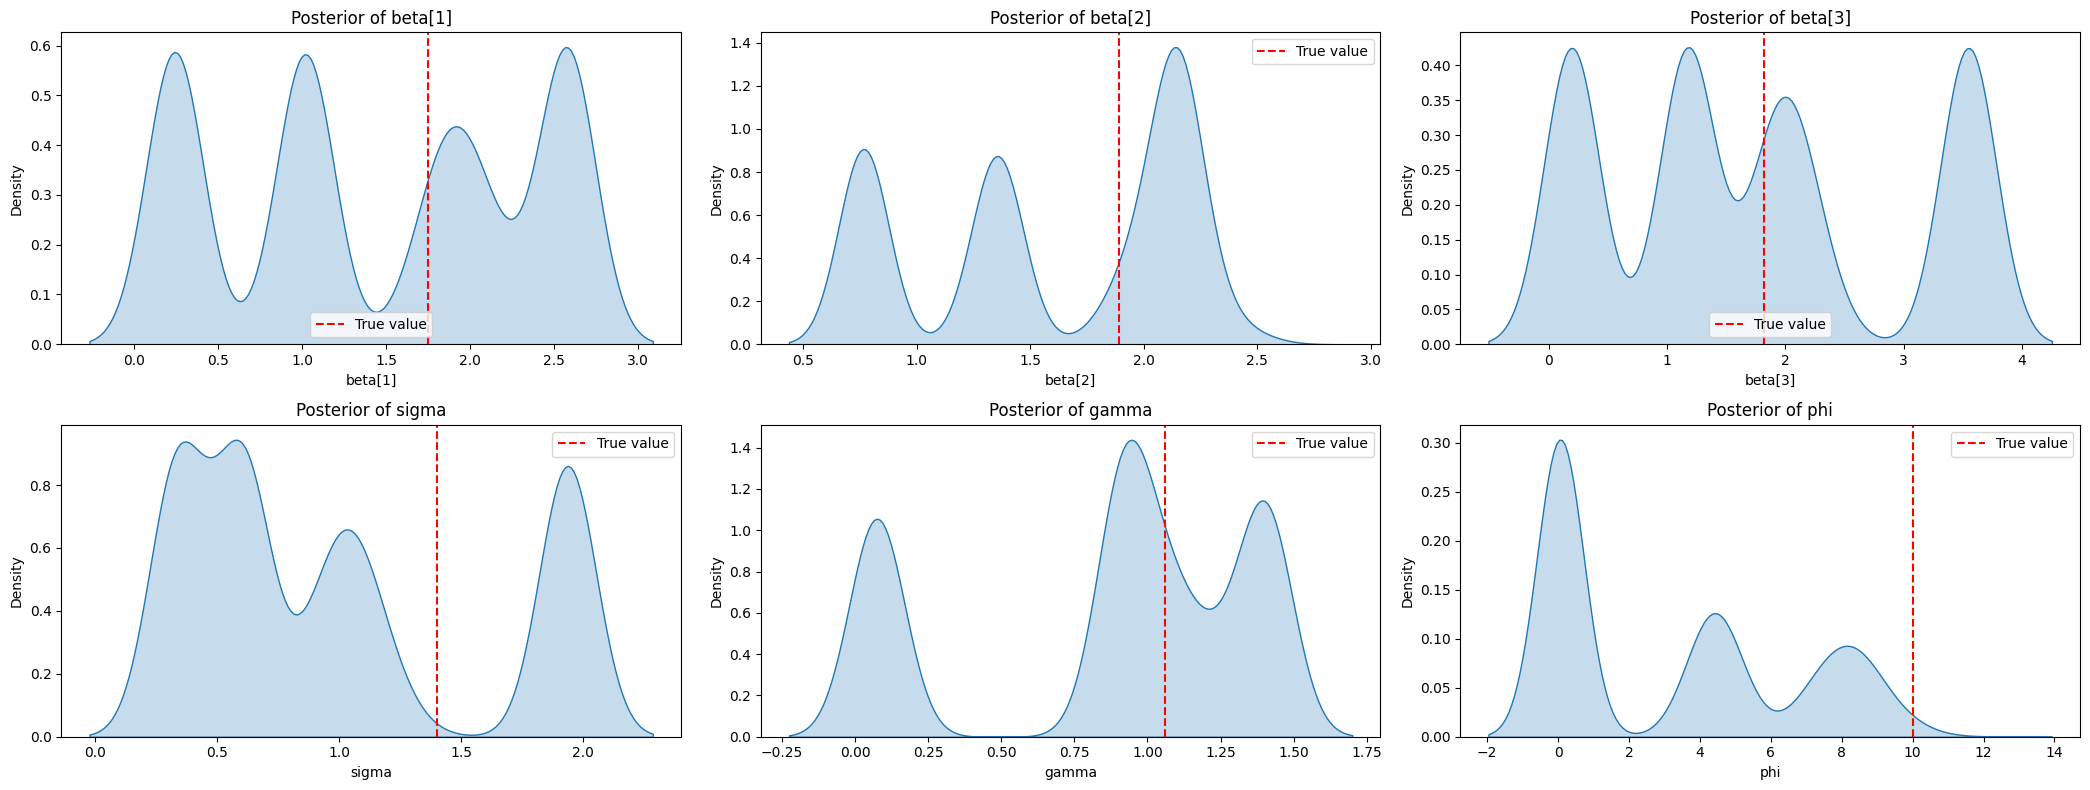

In [ ]:
parameters = ["beta[1]","beta[2]", "beta[3]", 
                "sigma","gamma", 'phi']
                
t = {'beta[1]': beta[0], 'beta[2]': beta[1], 'beta[3]': beta[2],
    'sigma': sigma, 'gamma': gamma,
    'phi': phi , 'reporting_rate':1}

plot_posterior_kde_grid(fit_multi_model, parameters=parameters, n_cols=3, true_values=t)

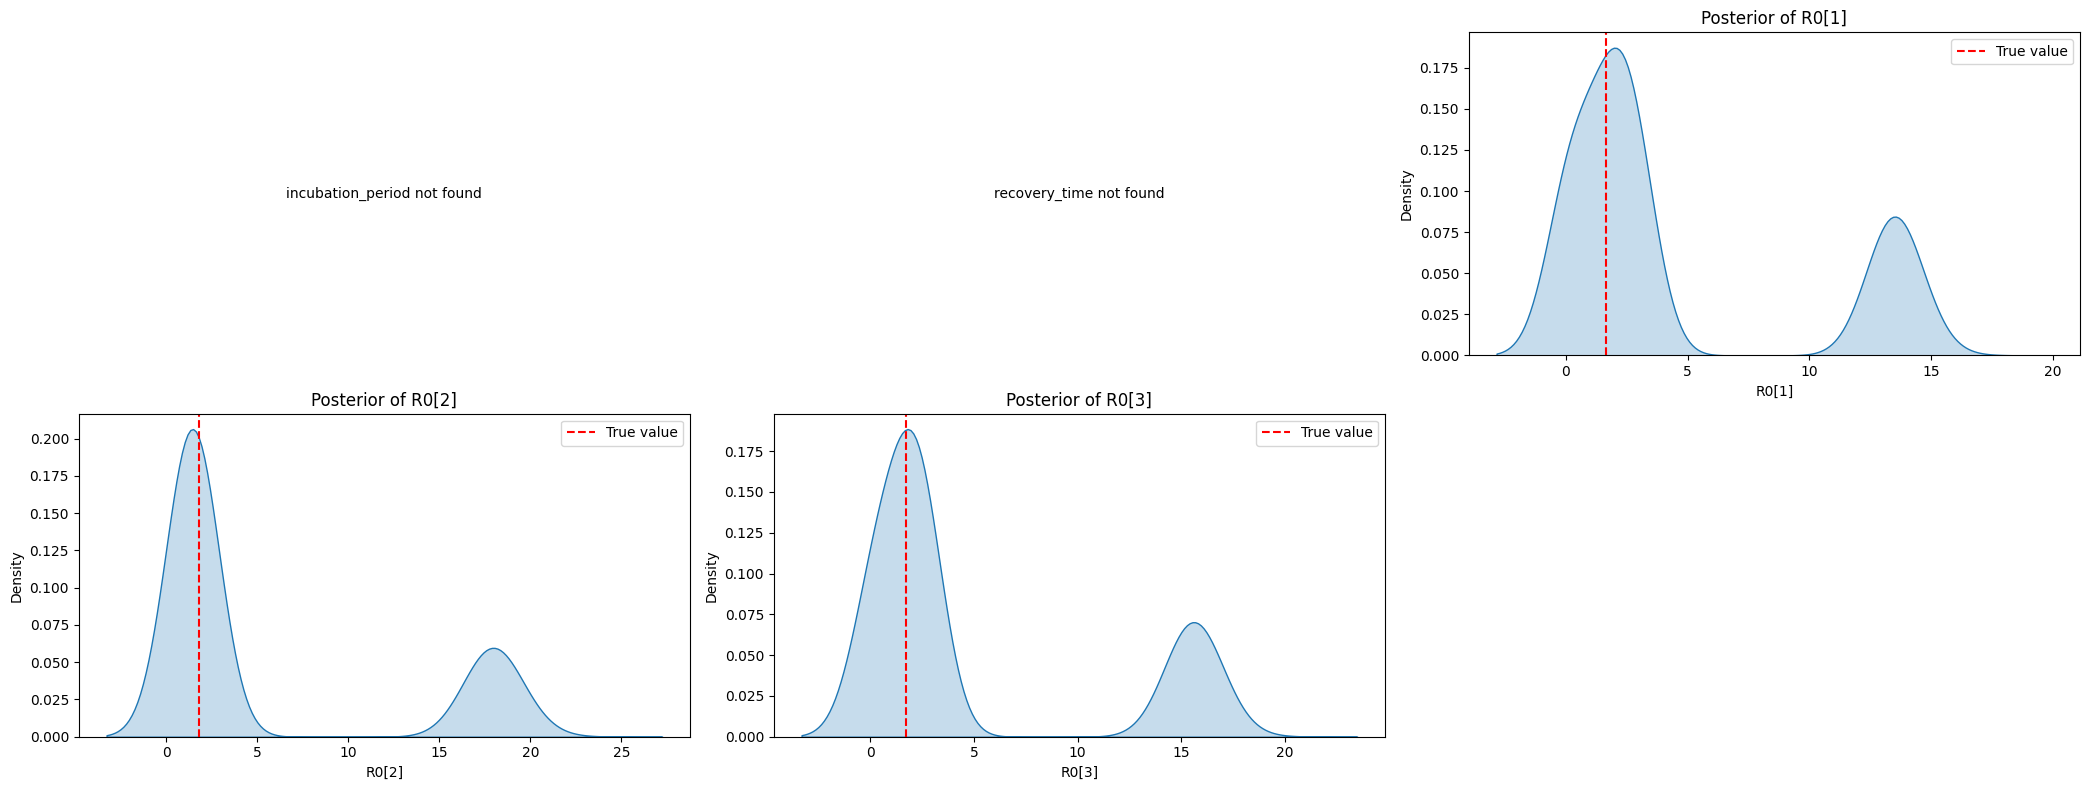

In [ ]:
parameters1 = ["incubation_period","recovery_time",
                "R0[1]","R0[2]", "R0[3]"]
t1 = {
    'R0[1]': r[0], 'R0[2]': r[1], 'R0[3]': r[2], 
    'recovery_time':rec,
    'incubation_period': incu}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1)

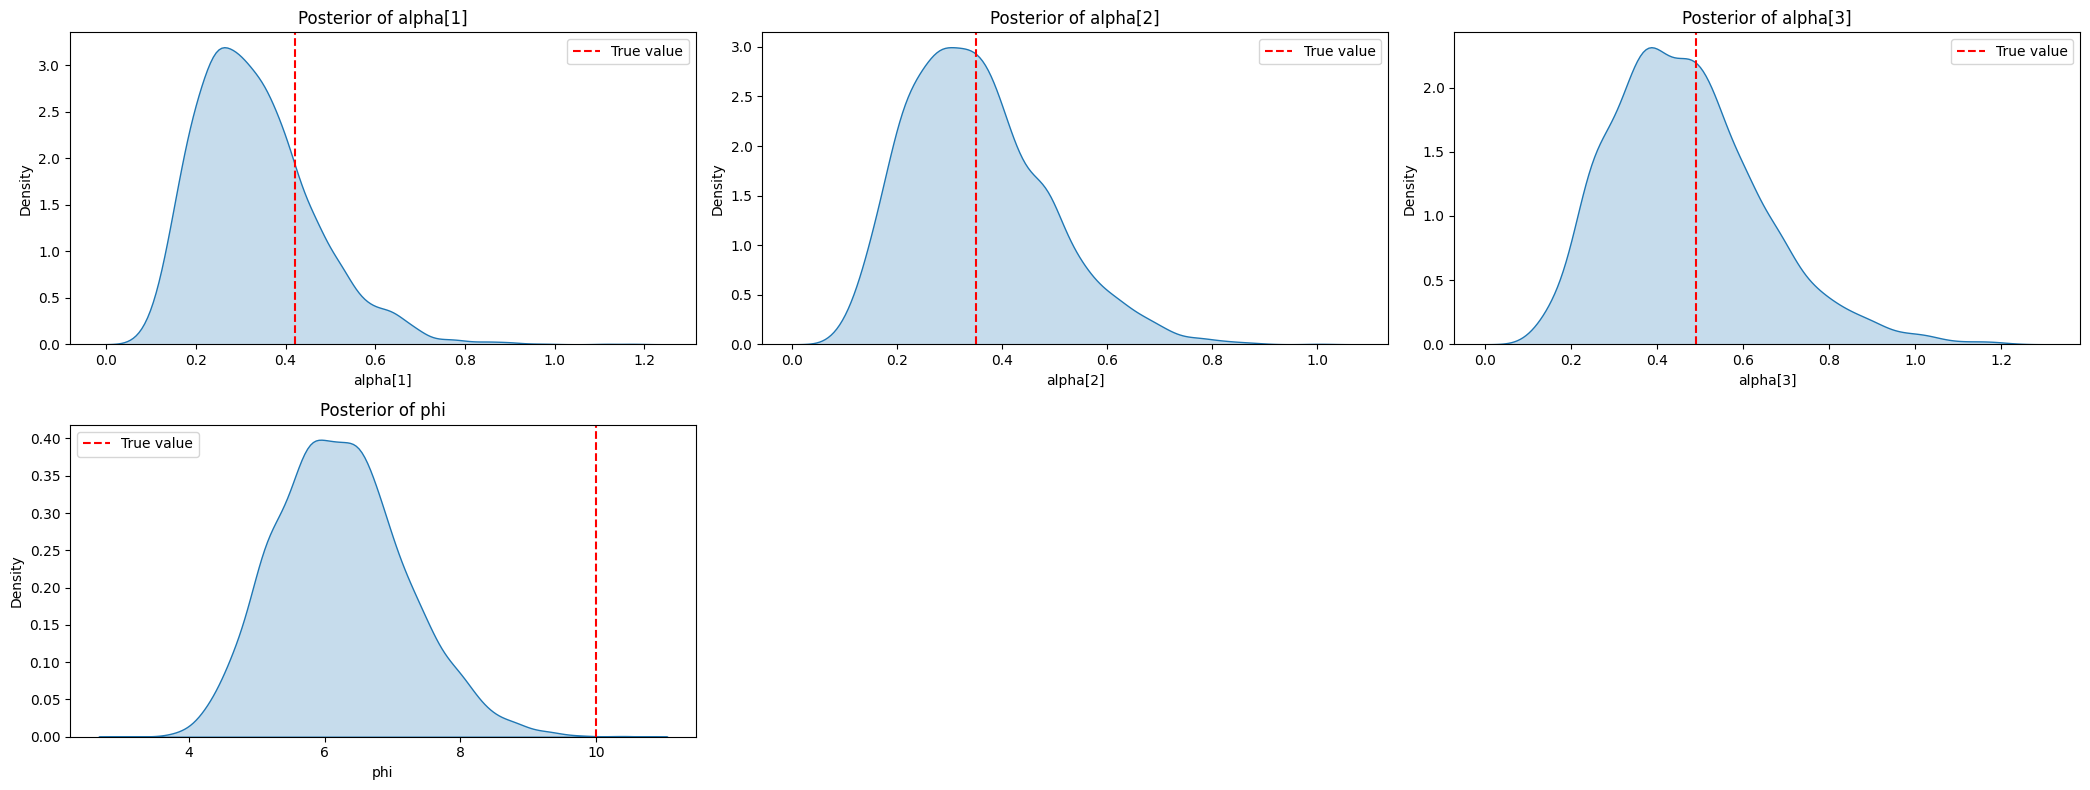

In [ ]:
parameters1 = ['phi']
t1 = {'phi': phi}


plot_posterior_kde_grid(fit_multi_model, parameters=parameters1, 
                        n_cols=3, true_values=t1, save = 'Checks_for_alphaPhi')

# PRIOR PREDICTIVE CHECK

In [ ]:

model_prior = CmdStanModel(stan_file = 'stan files/multi_patch_PRIOR.stan')
prior_check = model_prior.sample(data = seir_data,
                                     iter_sampling = 1000,
                                     chains = 4,
                                     seed = 0)

chain 1 |          | 00:00 Status


chain 1 |▉         | 00:18 Iteration:    1 / 2000 [  0%]  (Warmup)


chain 1 |█▎        | 01:41 Iteration:  100 / 2000 [  5%]  (Warmup)

chain 1 |█▊        | 02:10 Iteration:  200 / 2000 [ 10%]  (Warmup)
chain 1 |██▎       | 02:14 Iteration:  300 / 2000 [ 15%]  (Warmup)




















chain 1 |██▋       | 08:19 Iteration:  400 / 2000 [ 20%]  (Warmup)

chain 1 |███▏      | 08:22 Iteration:  500 / 2000 [ 25%]  (Warmup)

chain 1 |███▋      | 08:27 Iteration:  600 / 2000 [ 30%]  (Warmup)

chain 1 |████      | 08:42 Iteration:  700 / 2000 [ 35%]  (Warmup)

chain 1 |████▌     | 08:44 Iteration:  800 / 2000 [ 40%]  (Warmup)

chain 1 |█████▍    | 08:56 Iteration: 1000 / 2000 [ 50%]  (Warmup)

chain 1 |████████▏ | 09:34 Iteration: 1500 / 2000 [ 75%]  (Sampling)

chain 1 |████████▋ | 09:40 Iteration: 1600 / 2000 [ 80%]  (Sampling)

chain 1 |█████████ | 09:55 Iteration: 1700 / 2000 [ 85%]  (Sampling)

chain 1 |█████████▌| 09:58 Iteration: 1800 / 2000 [ 90%

In [ ]:
import math
def plot_prior(model, param_names, boundary, ncols=3, 
               figsize_per_plot=(8, 7), 
               sharey=True, 
               legend_on_first=True):
    

    countries = ['Guinea','Liberia','Sierra Leone']
    n_params = len(param_names)
    nrows   = math.ceil(n_params / ncols)
    fig_w   = figsize_per_plot[0] * ncols
    fig_h   = figsize_per_plot[1] * nrows+1
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(fig_w, fig_h))
    
    # flatten even if nrows or ncols == 1
    axes = np.array(axes).reshape(-1)
    
    for i, (ax, pname) in enumerate(zip(axes, param_names)):
        # pull samples: shape (n_samples, n_patches)
        samples = model.stan_variable(pname)
        df = pd.DataFrame(samples, columns=countries)
        
        # plot densities
        df.plot(kind='density', ax=ax, legend=False)
        ax.set_title(f'Prior predictive check for {pname}')
        ax.set_xlabel(pname)
        ax.grid(True)
        ax.axvline(x=boundary[i*2], color='r')
        ax.axvline(x=boundary[i*2+1], color='r')
    
    # hide any unused axes
    for ax in axes[n_params:]:
        ax.set_visible(False)

    
    # add legend if desired
    if legend_on_first and n_params > 0:
        axes[0].legend(countries, title='Patch')
    
    plt.tight_layout()
    return fig, axes


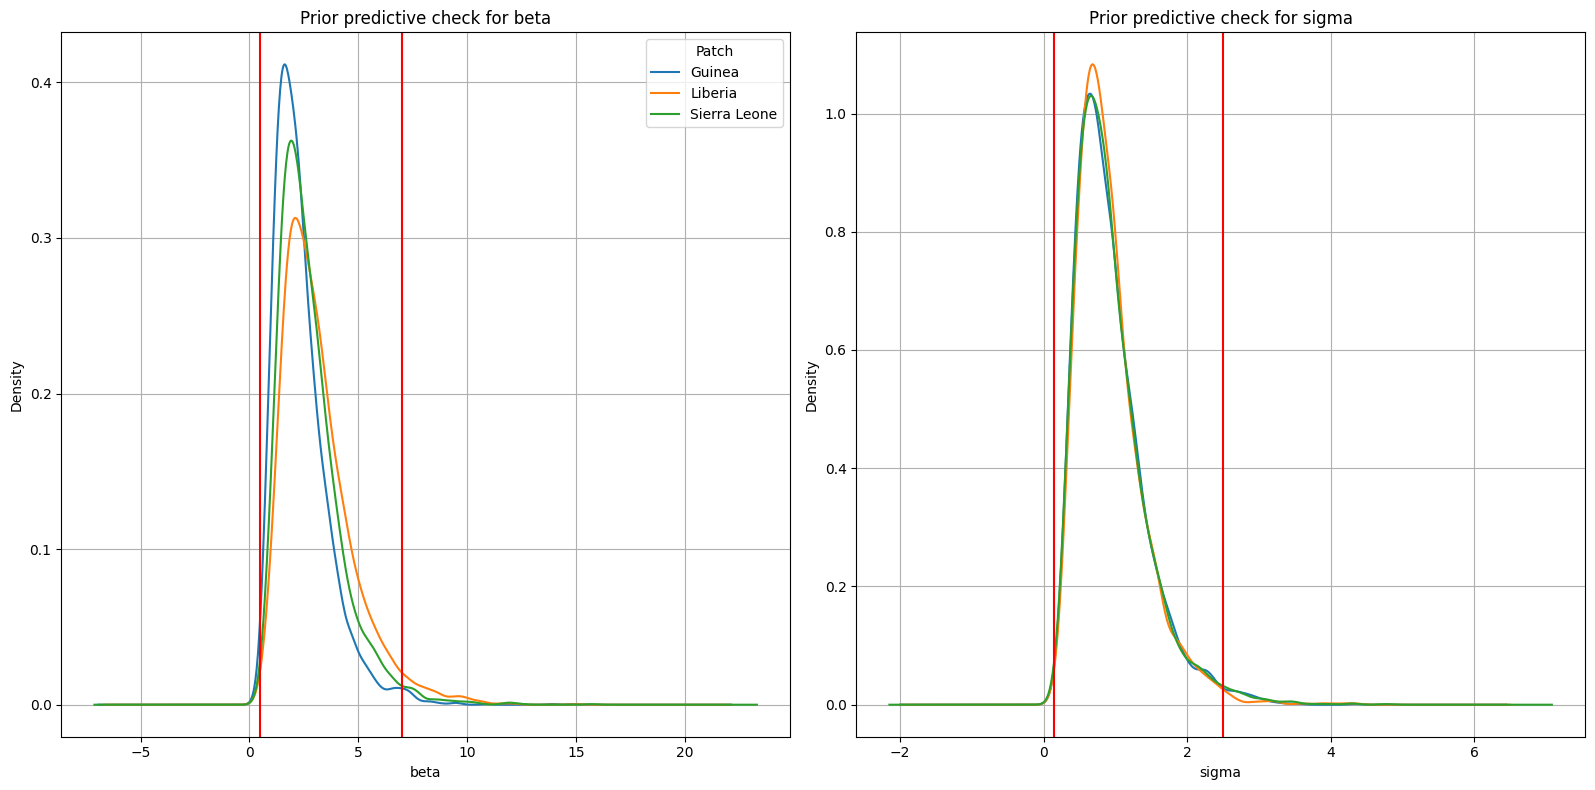

In [ ]:
params = ['beta','sigma', 'gamma']
boundaries = [0.5, 7, 0.14, 2.5, 0.1, 2.0]

# 5 parameters → grid of 2×3 (since ncols=3)
fig, axes = plot_prior(prior_check, params, boundary = boundaries, ncols=3)
plt.show()

In [ ]:
# infection_draws = prior_check.draws_pd("y")
# lines = plt.plot(range(1,15),
#                  infection_draws,
#                  color = "k", alpha = 0.1)
# plt.axhline(y=N[0], color='r', linestyle='--')
# plt.xlabel('Time')
# plt.ylabel('Number of infections')
# plt.show()

# R0

from sympy import *
init_printing()